In [1]:
import os
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from pandas import DataFrame
from torch.utils.data import DataLoader
from tqdm import tqdm

# Add PARENT dir (where thesis_utils lives)
parent_dir = Path.cwd().parent  # /src/
sys.path.insert(0, str(parent_dir))

print(f"Added to path: {str(parent_dir)}")
print(f"thesis_utils exists: {os.path.exists(parent_dir / 'thesis_utils')}")

# Reload
%reload_ext autoreload
%autoreload 2

# Now import works
import thesis_utils as tu

Added to path: /Users/gabriel/Documents/01_TUW/00_Thesis/trade_under_pressure_thesis/src
thesis_utils exists: True


# Data Preparation

In [2]:
BASE_FONT = "DejaVu Sans"

matplotlib.rcParams.update({
  "font.family": BASE_FONT,

  # Big base size
  "font.size": 14,

  # Titles
  "axes.titlesize": 20,
  "figure.titlesize": 18,

  # Axis labels
  "axes.labelsize": 18,

  # Legend
  "legend.fontsize": 16,

  # Ticks
  "xtick.labelsize": 14,
  "ytick.labelsize": 14,

  # Lines
  "axes.linewidth": 1.5,
})

# Seaborn setup
custom_rc = {
  "axes.spines.right": False,
  "axes.spines.top": False,
  "axes.edgecolor": "#03071e",
  "grid.linestyle": "dashdot",
  "grid.color": "#4a5759",
  "axes.facecolor": "#edf2fb",
  "patch.edgecolor": "#3c6e71",
  "axes.titlesize": 20,
  "axes.labelsize": 18,
  "xtick.labelsize": 14,
  "ytick.labelsize": 14,
  "legend.fontsize": 16,
}
sns.set_theme(style="whitegrid", rc=custom_rc, font=BASE_FONT)
colors = sns.color_palette("magma")

In [3]:
# Model parameters
HORIZON = 1
BATCH_SIZE = 800
NUM_EPOCHS = 25
HIDDEN_SIZE = 128
N_LAYERS = 3
DROPOUT = 0.3
EMBEDDING_SIZE = 32

# Train parameters
TARGET = "EXPORT_centered"
FEATURES = [
  "contig", "comlang_off", "colony", "smctry",  # dist cepii categorical
]
N_SPLITS = 5
PATIENCE = 5
LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.01
RANDOM_SEED = 16
KEEP_FRAC = 1.0
N_LAGS = 5
SUBSAMPLE_ENABLED = False
N_DYADS = 1000

SANCTION_COLS = ["arms", "military", "trade", "travel", "other", "financial"]

# Torch config
torch.manual_seed(RANDOM_SEED)
device = (
  torch.device("mps") if torch.backends.mps.is_available()
  else torch.device("cpu")
)

DYADS_CASE_STUDY = [
  "USA_CHN", "CHN_USA",
  "USA_DEU", "DEU_USA",
  "USA_JPN", "JPN_USA",
  "USA_RUS", "RUS_USA",
  "DEU_CHN", "CHN_DEU",
  "DEU_JPN", "JPN_DEU",
  "DEU_RUS", "RUS_DEU",
  "JPN_CHN", "CHN_JPN",
  "JPN_RUS", "RUS_JPN",
  "CHN_RUS", "RUS_CHN",
]
some_dyads = ["TUR_IRN", "IRN_TUR", "IND_RUS", "RUS_IND", "BRA_VEN", "VEN_BRA", "IRN_CHN", "CHN_IRN", "UKR_RUS",
              "RUS_UKR"]
EXTRA_DYADS = False
if EXTRA_DYADS:
  DYADS_CASE_STUDY += some_dyads

In [4]:
processed = pd.read_parquet(path="../../data/model/processed.parquet", engine="fastparquet")

df_nn: DataFrame = processed.copy(deep=True)
df_nn["dyad_id"] = df_nn["ISO3_reporter"] + "_" + df_nn["ISO3_partner"]
df_nn = df_nn.sort_values(by=["dyad_id", "Year"], ignore_index=True)

# Prepare sanction column as sum of all active boolean sanctions
df_nn["sanction"] = (df_nn[SANCTION_COLS]
                     .sum(axis=1)).astype(int)

# Coerce numerical columns to float
num_cols = ["distw", "GDP_reporter", "GDP_partner", "sanction", "contig",
            "comlang_off", "colony", "smctry", "Year", ]
df_nn[num_cols] = df_nn[num_cols].apply(pd.to_numeric, errors="coerce").astype(float)

# Drop NA in numerical columns
df_nn = df_nn.dropna(subset=num_cols)

# Cast "Year" to integer
df_nn["Year"] = df_nn["Year"].astype(int)

# Cast "dyad_id" to categorical
for col in ["dyad_id"]:
  df_nn[col] = pd.Categorical(df_nn[col], categories=sorted(df_nn[col].unique()))

# Define and center columns
center_columns = ["distw", "GDP_reporter", "GDP_partner", "EXPORT"]
for col in center_columns:
  median = df_nn[col].median()
  std_df = df_nn[col].std()
  df_nn[col + "_centered"] = (df_nn[col] - median) / std_df

# Add "distw_centered" to feature list
FEATURES += ["distw_centered"]

# Define columns to be lagged and lag them while appending the number of the lag to the column name
lag_cols = ["GDP_reporter_centered", "GDP_partner_centered", "sanction"]
for col in lag_cols:
  for index in range(1, N_LAGS + 1):
    df_nn[f"{col}_lag{index}"] = df_nn.groupby("dyad_id", observed=True)[col].shift(index)

# Drop NA again for the lags that produced NA
df_nn = df_nn.dropna()

# Add lagged column names to the feature list
FEATURES += [f"{c}_lag{index}" for c in lag_cols for index in range(1, N_LAGS + 1)]

In [5]:
df_nn

,ISO3_reporter,UNDS_reporter,CNAME_reporter,ISO3_partner,UNDS_partner,CNAME_partner,Year,GDP_reporter,GDP_partner,contig,...,GDP_partner_centered_lag1,GDP_partner_centered_lag2,GDP_partner_centered_lag3,GDP_partner_centered_lag4,GDP_partner_centered_lag5,sanction_lag1,sanction_lag2,sanction_lag3,sanction_lag4,sanction_lag5
5,AGO,024,Angola,ALB,008,Albania,1993,5.768720e+09,1.185315e+09,0.0,...,-0.012576,-0.012233,-0.011522,-0.011350,-0.011504,0.0,0.0,0.0,0.0,0.0
6,AGO,024,Angola,ALB,008,Albania,1994,4.438321e+09,1.880951e+09,0.0,...,-0.012167,-0.012576,-0.012233,-0.011522,-0.011350,0.0,0.0,0.0,0.0,0.0
7,AGO,024,Angola,ALB,008,Albania,1995,5.538749e+09,2.392765e+09,0.0,...,-0.011635,-0.012167,-0.012576,-0.012233,-0.011522,0.0,0.0,0.0,0.0,0.0
8,AGO,024,Angola,ALB,008,Albania,1996,7.526447e+09,3.199641e+09,0.0,...,-0.011243,-0.011635,-0.012167,-0.012576,-0.012233,0.0,0.0,0.0,0.0,0.0
9,AGO,024,Angola,ALB,008,Albania,1997,7.648377e+09,2.258514e+09,0.0,...,-0.010624,-0.011243,-0.011635,-0.012167,-0.012576,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178542,ZWE,716,Zimbabwe,ZMB,894,Zambia,2018,3.415607e+10,2.631151e+10,1.0,...,0.006744,0.002979,0.003204,0.007715,0.008402,0.0,0.0,0.0,0.0,0.0
1178543,ZWE,716,Zimbabwe,ZMB,894,Zambia,2019,2.571741e+10,2.330867e+10,1.0,...,0.007080,0.006744,0.002979,0.003204,0.007715,0.0,0.0,0.0,0.0,0.0
1178544,ZWE,716,Zimbabwe,ZMB,894,Zambia,2020,2.686794e+10,1.813776e+10,1.0,...,0.004780,0.007080,0.006744,0.002979,0.003204,0.0,0.0,0.0,0.0,0.0
1178545,ZWE,716,Zimbabwe,ZMB,894,Zambia,2021,2.724052e+10,2.209642e+10,1.0,...,0.000819,0.004780,0.007080,0.006744,0.002979,0.0,0.0,0.0,0.0,0.0


# Load trained models and create dataloader

In [89]:
# 1) Load all models
checkpoints = {
  "LSTM": torch.load(
    "../../models/LSTM-0_0003lr-0_15d-512hs-0_01wd-2048bs-3layers-256es-kfolds8-hp.pt",
    map_location="cpu"
  ),
  "GRU": torch.load(
    "../../models/GRU-0_0003lr-0_15d-512hs-0_001wd-2048bs-3layers-256es-kfolds8-hp.pt",
    map_location="cpu"
  ),
  "SLSTM": torch.load(
    "../../models/SLSTM-1e-05lr-0_05d-512hs-0_001wd-2048bs-3layers-256es-kfolds8-hp.pt",
    map_location="cpu"
  ),
  "MLSTM": torch.load(
    "../../models/MLSTM-1e-05lr-0_05d-512hs-0_001wd-2048bs-3layers-256es-kfolds8-hp.pt",
    map_location="cpu"
  ),
  # "XLSTM(smsm)": torch.load(
  #   "../../models/XLSTM(smsm)-0_0003lr-0_15d-512hs-0_005wd-2048bs-3layers-256es-kfolds8-hp_horizon-3.pt",
  #   map_location="cpu"
  # ),
  "XLSTM(sm)": torch.load(
    "../../models/XLSTM(sm)-0_0003lr-0_15d-512hs-0_005wd-2048bs-3layers-256es-kfolds8-hp_horizon-1.pt",
    map_location="cpu"
  )
}

# Save all models in a dictionary
models = { }
for name, ckpt in checkpoints.items():
  if name.startswith("GRU"):
    m = tu.DyadGRU(**ckpt["model_hyperparams"])
  elif name.startswith("LSTM"):
    m = tu.DyadLSTM(**ckpt["model_hyperparams"])
  elif name.startswith("XLSTM"):
    m = tu.DyadXLSTM(**ckpt["model_hyperparams"])
  else:
    m = tu.DyadXLSTM(**ckpt["model_hyperparams"])

  state_dict = ckpt["model_state_dict"]

  # Remove torch.compile / wrapper prefix
  clean_state_dict = {
    k.replace("_orig_mod.", ""): v
    for k, v in state_dict.items()
  }

  m.load_state_dict(clean_state_dict)
  print(ckpt["model_hyperparams"])
  m.to(device).eval()
  models[name] = m

# 2) Build the dataset & dataloader once
dataset, dyad_to_idx = tu.make_panel_datasets_dyad_year(
  data=df_nn, features=FEATURES, target=TARGET, horizon=HORIZON
)

loader = DataLoader(
  dataset, batch_size=BATCH_SIZE, shuffle=False,
  num_workers=10, persistent_workers=True, prefetch_factor=2
)

{'n_features': 20, 'n_dyads': 33672, 'embed_dim': 256, 'hidden_size': 512, 'n_layers': 3, 'dropout': 0.15, 'horizon': 1}
{'n_features': 20, 'n_dyads': 33672, 'embed_dim': 256, 'hidden_size': 512, 'n_layers': 3, 'dropout': 0.15, 'horizon': 1}
{'n_features': 20, 'n_dyads': 33672, 'n_layers': 3, 'embed_dim': 256, 'hidden_size': 512, 'dropout': 0.05, 'horizon': 1, 'type': 'S', 'layers': 'sm'}
{'n_features': 20, 'n_dyads': 33672, 'n_layers': 3, 'embed_dim': 256, 'hidden_size': 512, 'dropout': 0.05, 'horizon': 1, 'type': 'M', 'layers': 'sm'}
{'n_features': 20, 'n_dyads': 33672, 'n_layers': 3, 'embed_dim': 256, 'hidden_size': 512, 'dropout': 0.15, 'horizon': 1, 'type': 'X', 'layers': 'sm'}


# Additional check to see if the model is predicting the mean

In [90]:
# Check if the model is predicting the mean
all_preds = { name: [] for name in models }
all_truth = []
all_years = []

with torch.no_grad():
  for X, y, di, yr in tqdm(loader, desc="Predicting", unit="batch"):
    X, di = X.to(device), di.to(device)
    # collect truth & years once
    all_truth.append(y)
    all_years.append(yr)

    for name, m in models.items():
      y_hat = m(X, di).cpu()
      all_preds[name].append(y_hat)

Predicting: 100%|██████████| 1263/1263 [00:28<00:00, 43.58batch/s]


In [91]:
years = torch.cat(all_years).numpy().flatten()
truth = torch.cat(all_truth).numpy().flatten()
for name in all_preds:
  all_preds[name] = torch.cat(all_preds[name]).numpy().flatten()

In [92]:
# 4) Invert centering back to exports
med = df_nn["EXPORT"].median()
sd = df_nn["EXPORT"].std()

truth = truth * sd + med
pred = { name: preds * sd + med for name, preds in all_preds.items() }

In [93]:
global_mean = truth.mean().item()

In [94]:
from sklearn.metrics import r2_score

mean_pred = np.full_like(truth, global_mean)

print(f"Baseline (mean model) R²: {r2_score(truth, mean_pred):.4f}")
for name, y_pred in pred.items():
  print(f"{name} R²: {r2_score(truth, y_pred):.4f}")

Baseline (mean model) R²: 0.0000
LSTM R²: 0.9185
GRU R²: 0.9187
SLSTM R²: 0.9259
MLSTM R²: 0.9260
XLSTM(sm) R²: 0.9160


In [95]:
print(f"STD of true values: {np.std(truth):.4f}")
print(f"STD of mean predictions: {np.std(mean_pred):.4f}")
for name, y_pred in pred.items():
  print(f"STD of {name} predictions: {np.std(y_pred):.4f}")

STD of true values: 4875352.0000
STD of mean predictions: 0.0625
STD of LSTM predictions: 4839175.5000
STD of GRU predictions: 4845147.5000
STD of SLSTM predictions: 4855637.0000
STD of MLSTM predictions: 4548072.0000
STD of XLSTM(sm) predictions: 4755179.5000


# TC-SHAP

In [96]:
# Extract dyads to be observed
FEATURE_LEN = len(FEATURES)
SELECTED_MODEL = "XLSTM(sm)"
# Prepare model
model_tc_shap = models[SELECTED_MODEL]
model_tc_shap.eval()
model_tc_shap.to(device)

DyadXLSTM(
  (dyad_embed): Embedding(33672, 256)
  (xlstm): xLSTM(
    (layers): ModuleList(
      (0): sLSTMBlock(
        (layer_norm): LayerNorm((276,), eps=1e-05, elementwise_affine=True)
        (causal_conv): CausalConv1D(
          (conv): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=(3,))
        )
        (Wz): BlockDiagonal(
          (blocks): ModuleList(
            (0): Linear(in_features=276, out_features=512, bias=True)
          )
        )
        (Wi): BlockDiagonal(
          (blocks): ModuleList(
            (0): Linear(in_features=276, out_features=512, bias=True)
          )
        )
        (Wf): BlockDiagonal(
          (blocks): ModuleList(
            (0): Linear(in_features=276, out_features=512, bias=True)
          )
        )
        (Wo): BlockDiagonal(
          (blocks): ModuleList(
            (0): Linear(in_features=276, out_features=512, bias=True)
          )
        )
        (Rz): BlockDiagonal(
          (blocks): ModuleList(
            

In [97]:
top_dyad_idxs = [dyad_to_idx[d] for d in DYADS_CASE_STUDY if d in dyad_to_idx]

In [98]:
# Collect samples for selected dyads
X_list, dyad_idx_list = [], []

for i in range(len(dataset)):
  X, y, dyad_idx, _ = dataset[i]
  if dyad_idx.item() in top_dyad_idxs:
    X_list.append(X)
    dyad_idx_list.append(dyad_idx)

In [99]:
X_filtered = torch.cat(X_list)  # (N, 1, D)
dyad_filtered = torch.stack(dyad_idx_list)  # (N,)
flat_X = X_filtered.reshape(len(X_filtered), -1).numpy()  # (N, D)
dyads_np = dyad_filtered.numpy().reshape(-1, 1)  # (N, 1)
X_plus_dyad = np.concatenate([flat_X, dyads_np], axis=1)  # (N, D + 1)

In [100]:
# Split for SHAP
X_back = X_plus_dyad[:50]  # background dataset for kernel explainer
X_explain = X_plus_dyad[50:]  # data to explain

In [18]:
def make_predict_fn(model, n_features, device):
  def predict_fn(flat_X_dyad: np.ndarray):
    X_flat = flat_X_dyad[:, :-1]  # shape: (N, D)
    dyads = flat_X_dyad[:, -1].astype(int)
    X = torch.tensor(X_flat, dtype=torch.float32).reshape(-1, 1, n_features).to(device)
    dyads = torch.tensor(dyads, dtype=torch.long).to(device)
    with torch.no_grad():
      preds = model(X, dyads).cpu().numpy()
    return preds.reshape(-1)

  return predict_fn

In [19]:
# Run SHAP
predict_fn = make_predict_fn(model_tc_shap, n_features=len(FEATURES), device=device)
explainer = shap.KernelExplainer(predict_fn, X_back)
shap_values = explainer.shap_values(X_explain)

# Convert and aggregate
shap_vals = np.array(shap_values)  # shape: (N, D + 1)2
shap_vals_features_only = shap_vals[:, :-1]
avg_shap = np.mean(shap_vals_features_only, axis=0)  # shape: (D,)

  0%|          | 0/850 [00:00<?, ?it/s]

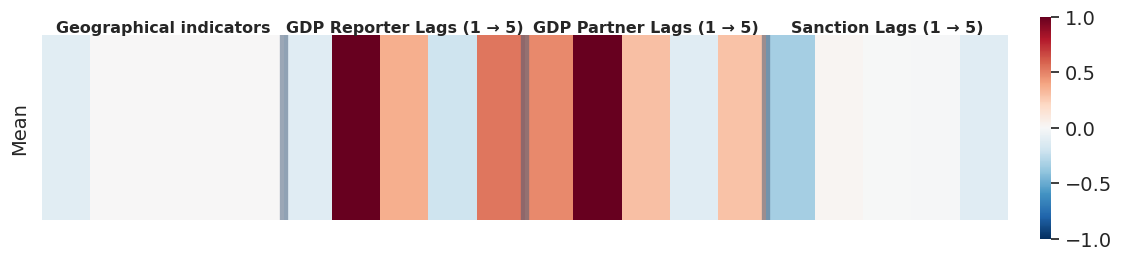

In [20]:
matplotlib.rcParams.update({
  "font.family": "DejaVu Sans",
})

plt.figure(figsize=(14, 2.4))

ax = sns.heatmap(
  avg_shap.reshape(1, -1),
  cmap="RdBu_r",
  vmin=-1,
  vmax=1,
  center=0,
  xticklabels=FEATURES,
  yticklabels=["Mean"],
  linewidths=0,
  cbar=True,
  cbar_kws={
    "fraction": 0.08,
    "pad": 0.03,
    "shrink": 1.2
  }
)

x_groups = [
  ("Geographical indicators", 2.5),
  ("GDP Reporter Lags (1 → 5)", 7.5),
  ("GDP Partner Lags (1 → 5)", 12.5),
  ("Sanction Lags (1 → 5)", 17.5),
]

for label, xpos in x_groups:
  ax.text(
    xpos,
    0,
    label,
    ha="center",
    va="bottom",
    fontsize=11.5,
    fontweight="bold",
    transform=ax.transData,
  )

# Remove colorbar label
cbar = ax.collections[0].colorbar
cbar.set_label("")

feature_blocks = {
  "geo": 5,
  "gdp_rep": 10,
  "gdp_part": 15
}

for x in feature_blocks.values():
  ax.vlines(x, *ax.get_ylim(), colors="#415a77", linewidth=6, alpha=0.5)

ax.set_xticklabels([""] * len(FEATURES))
ax.tick_params(axis="y", labelsize=14)

plt.savefig(
  f"../graph_output/shap_mean_{SELECTED_MODEL}.png",
  dpi=500,
  bbox_inches="tight"
)
plt.show()

In [21]:
avg_tc_shap_per_dyad = { }

for pair in DYADS_CASE_STUDY:
  print("pair:", pair)

  # --- ensure dyad exists ---
  if pair not in dyad_to_idx:
    print("  -> pair not in dyad_to_idx, skipping")
    continue

  dyad_pair_idx = { dyad_to_idx[pair] }
  X_list, dyad_idx_list = [], []

  # --- iterate dataset and filter by dyad ---
  for i in range(len(dataset)):
    X, y, dyad_idx, _ = dataset[i]

    # robust dyad index extraction (tensor-safe)
    dyad_id = int(dyad_idx.squeeze().cpu().numpy())

    if dyad_id in dyad_pair_idx:
      X_list.append(X)
      dyad_idx_list.append(dyad_idx)

  if len(X_list) == 0:
    print("  -> no samples found for dyad, skipping")
    continue

  # --- stack tensors ---
  X_filtered = torch.cat(X_list, dim=0)  # (N, 1, D)
  dyad_filtered = torch.stack(dyad_idx_list)  # (N,)

  # --- flatten X and append dyad index ---
  flat_X = X_filtered.reshape(len(X_filtered), -1).cpu().numpy()
  dyads_np = dyad_filtered.squeeze().cpu().numpy().reshape(-1, 1)
  X_plus_dyad = np.concatenate([flat_X, dyads_np], axis=1)

  # --- background / explain split ---
  n_back = min(10, len(X_plus_dyad))  # small but sufficient
  X_back = X_plus_dyad[:n_back]
  X_explain = X_plus_dyad

  if len(X_explain) == 0:
    print("  -> not enough samples for SHAP, skipping")
    continue

  # --- SHAP explainer ---
  predict_fn = make_predict_fn(
    model_tc_shap,
    n_features=len(FEATURES),
    device=device
  )

  explainer = shap.KernelExplainer(predict_fn, X_back)
  shap_values = explainer.shap_values(X_explain)

  # --- handle SHAP output correctly ---
  if isinstance(shap_values, list):
    shap_vals = shap_values[0]  # single-output model
  else:
    shap_vals = shap_values

  # remove dyad-index column
  shap_vals_features_only = shap_vals[:, :-1]

  # --- average SHAP per dyad ---
  avg_shap = shap_vals_features_only.mean(axis=0)

  avg_tc_shap_per_dyad[pair] = avg_shap

  print(f"  -> stored avg SHAP for dyad, shape={avg_shap.shape}")

pair: USA_CHN


  0%|          | 0/30 [00:00<?, ?it/s]

  -> stored avg SHAP for dyad, shape=(20,)
pair: CHN_USA


  0%|          | 0/30 [00:00<?, ?it/s]

  -> stored avg SHAP for dyad, shape=(20,)
pair: USA_DEU


...

  -> stored avg SHAP for dyad, shape=(20,)
pair: UKR_RUS


  0%|          | 0/30 [00:00<?, ?it/s]

  -> stored avg SHAP for dyad, shape=(20,)
pair: RUS_UKR


  0%|          | 0/30 [00:00<?, ?it/s]

  -> stored avg SHAP for dyad, shape=(20,)


In [22]:
avg_tc_shap_per_dyad

{'USA_CHN': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -4.40963646e-01,  2.44647218e+00,  8.55675766e-01,
        -2.37241891e-01,  1.77467668e+00,  2.93129441e+00,  3.68669206e+00,
         1.52193026e+00,  2.52883380e-01,  7.30007233e-01, -3.29179215e-01,
         0.00000000e+00,  0.00000000e+00,  2.14598404e-03, -2.11817161e-03]),
 'CHN_USA': array([0.        , 0.        , 0.        , 0.        , 0.        ,
        6.85864009, 7.78754613, 4.03692002, 1.71746513, 2.88553016,
        4.67780094, 6.32519838, 3.22727194, 1.563608  , 3.4541647 ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 'USA_DEU': array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -0.13608874,  1.63941398,  0.68158531, -0.10297374,  1.16766404,
         0.11278314,  0.23850224,  0.0348916 , -0.04541449,  0.        ,
         0.01653679,  0.02880119,  0.01518645, -0.00536349,  0.06242398]),
 'DEU_USA': array

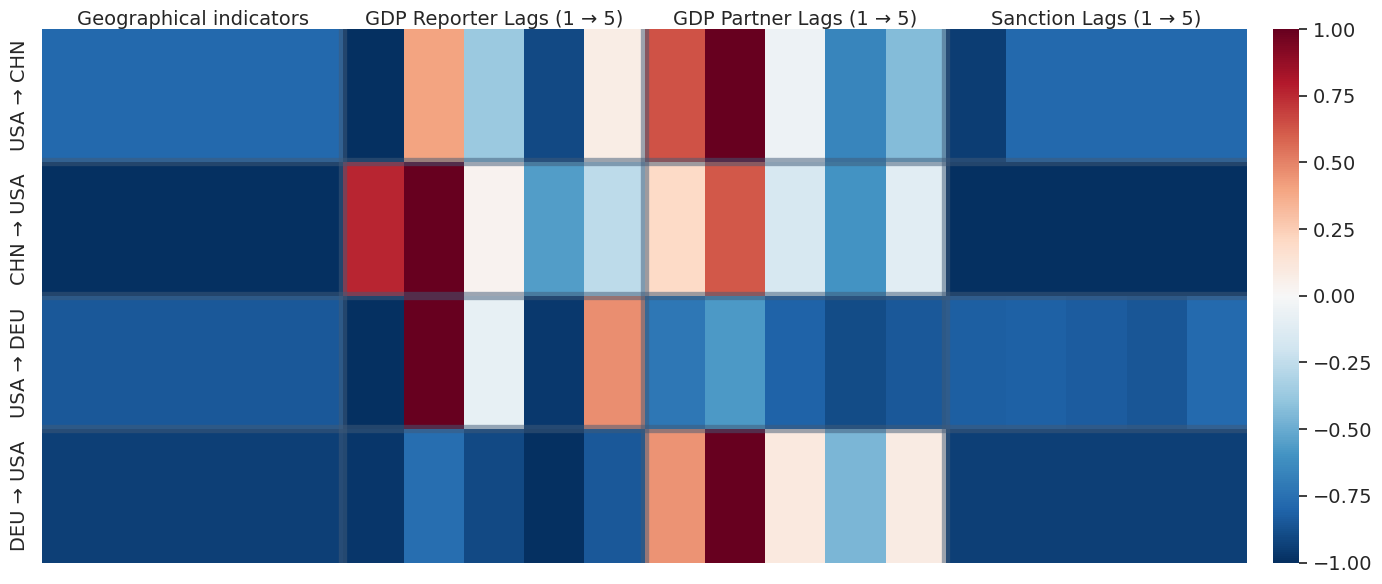

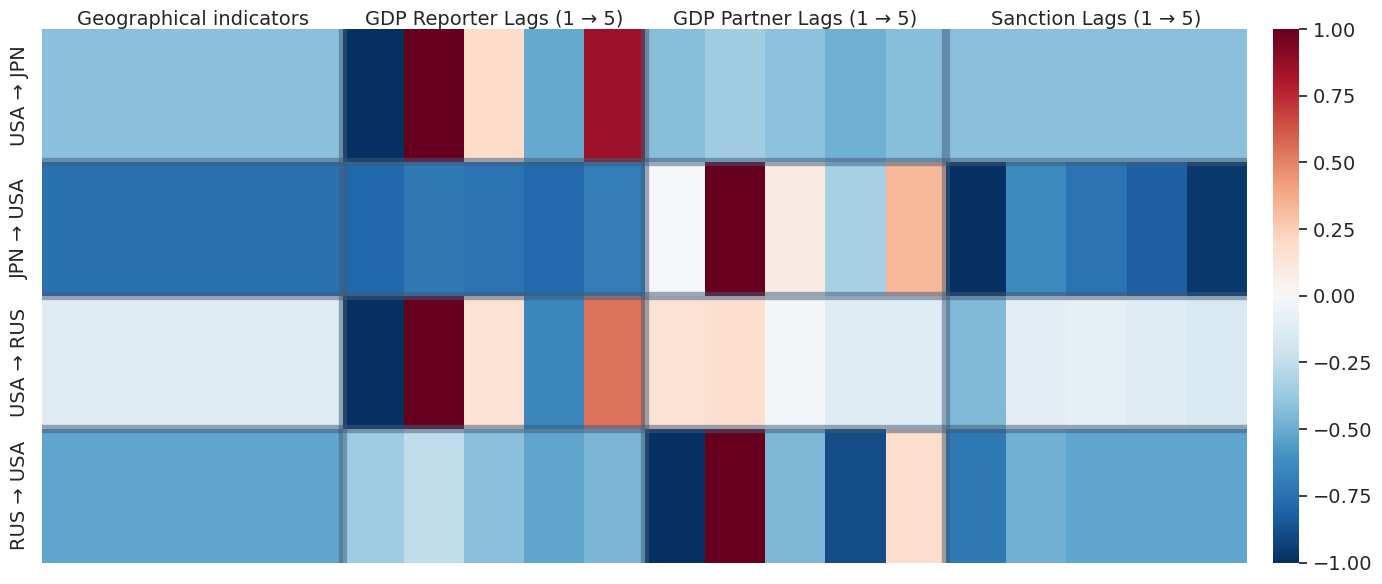

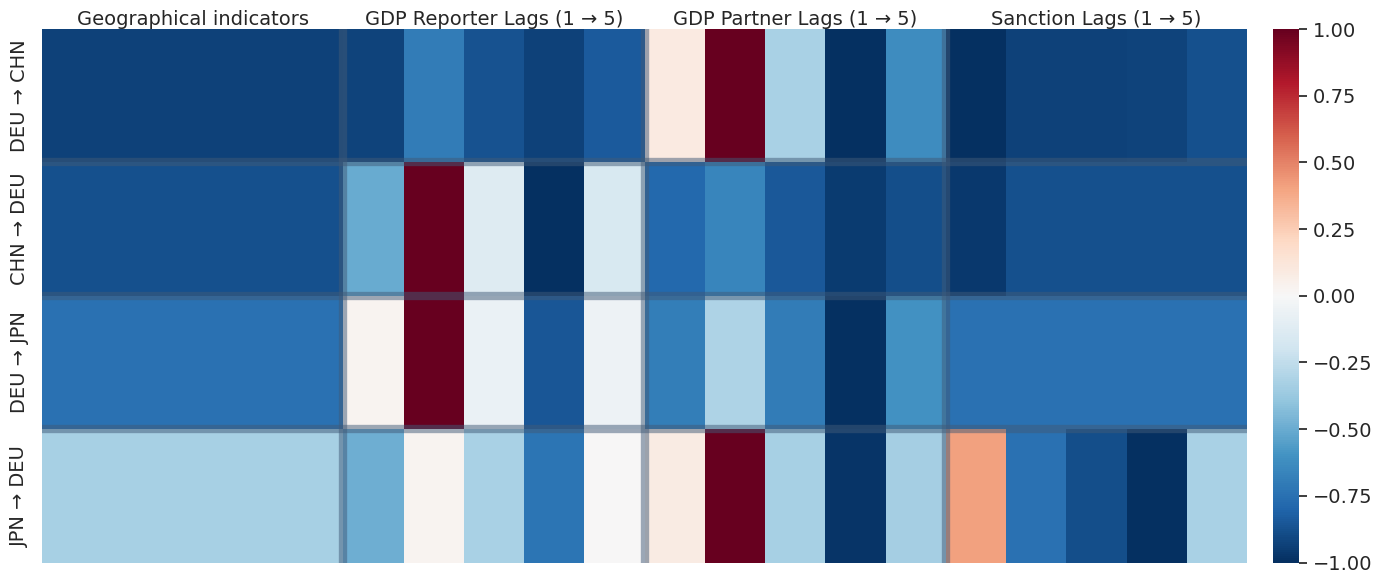

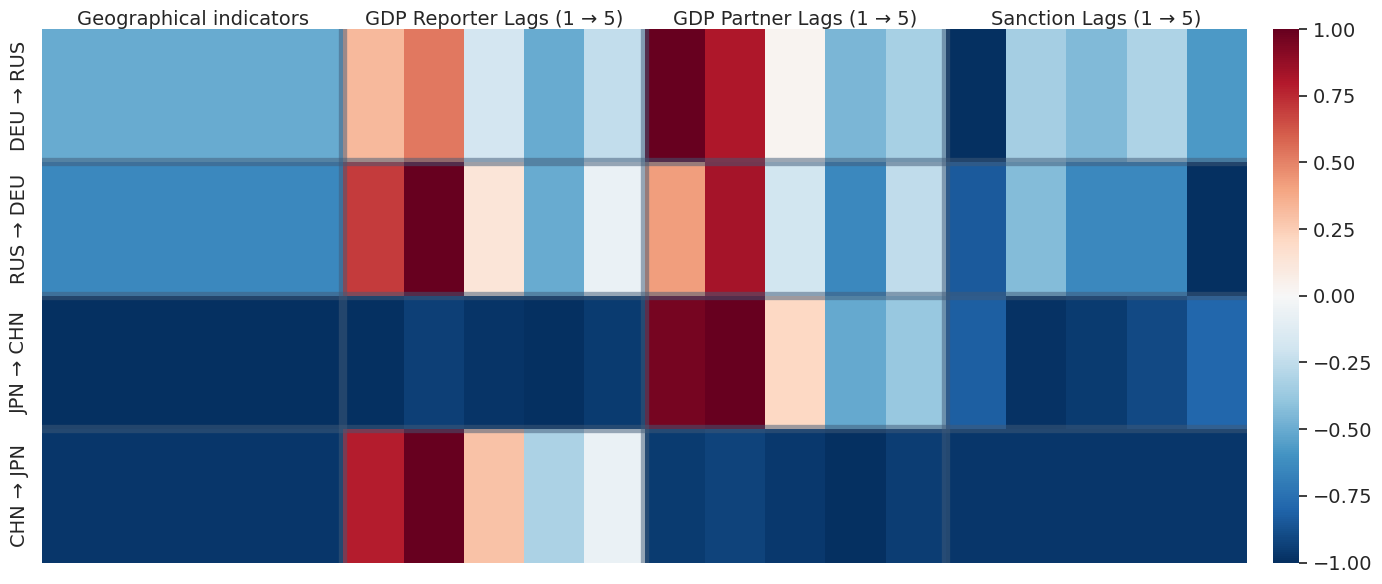

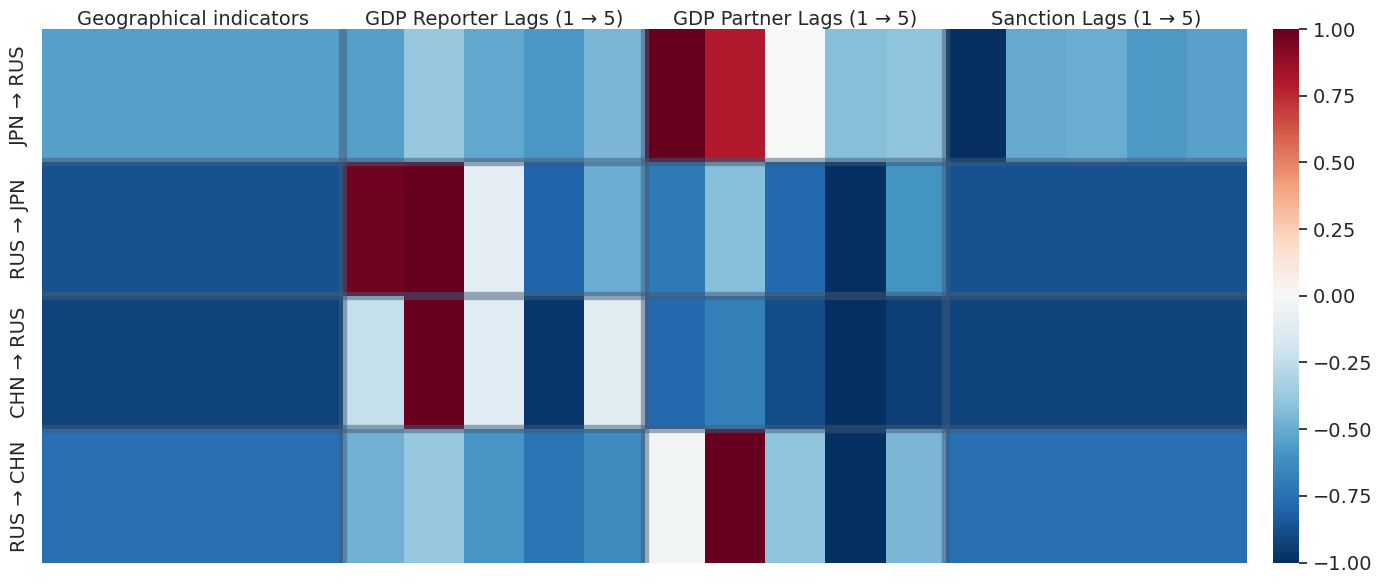

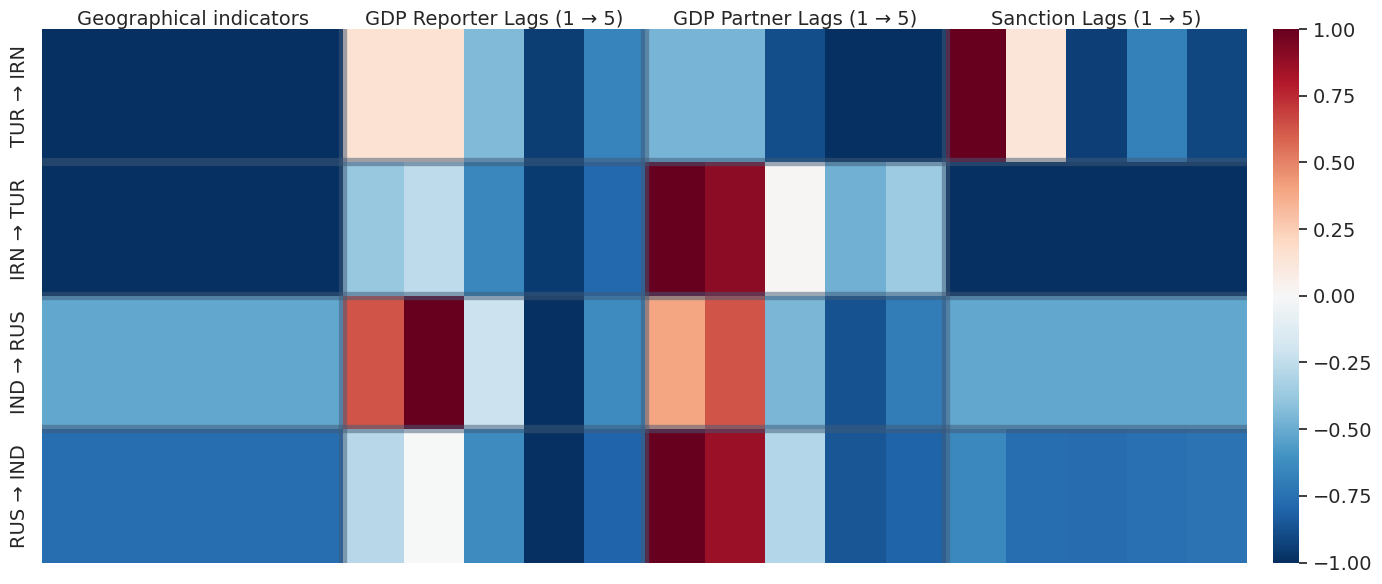

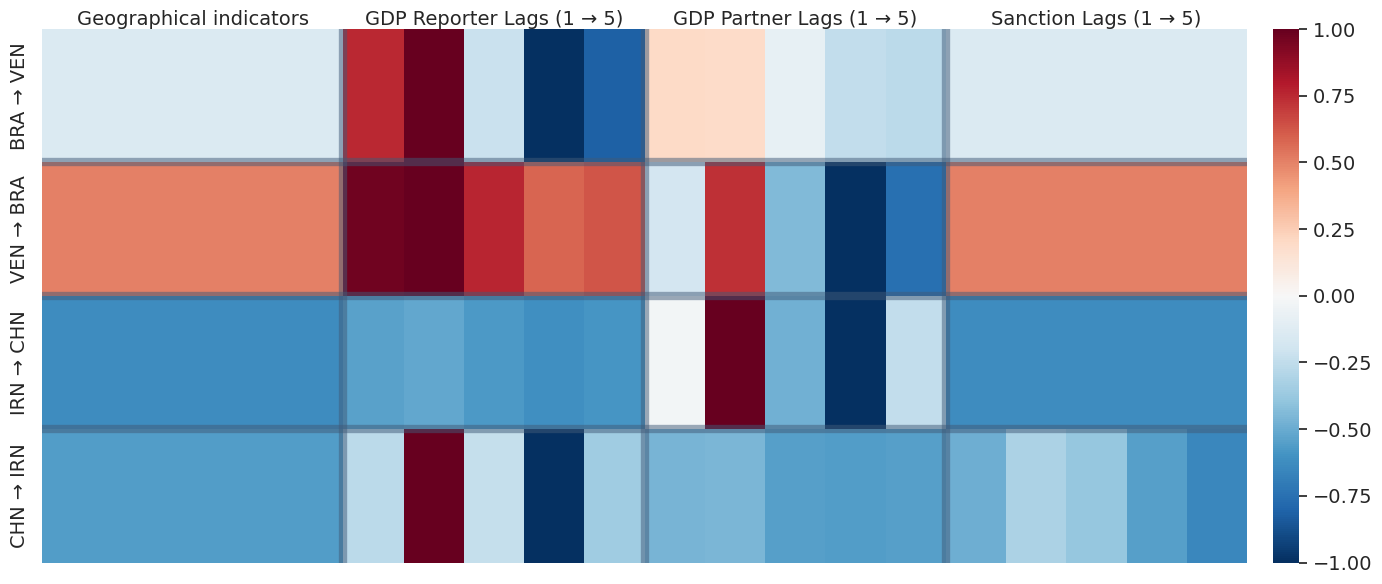

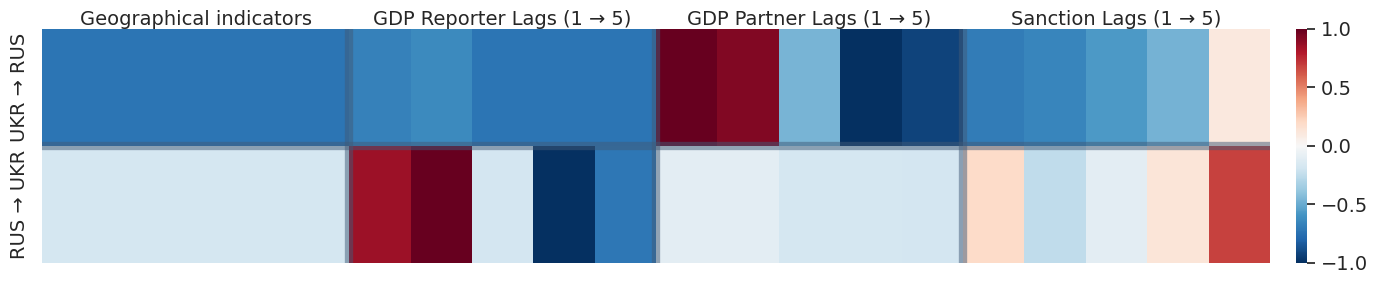

In [23]:
dyad_labels = []
heatmap_rows = []

for pair, shap_vals in avg_tc_shap_per_dyad.items():
  # pair is a string like "USA_CHN"
  dyad1, dyad2 = pair.split("_")

  avg_vals = shap_vals

  min_val = np.min(avg_vals)
  max_val = np.max(avg_vals)

  if max_val - min_val < 1e-8:
    scaled_vals = np.zeros_like(avg_vals)
  else:
    scaled_vals = 2 * (avg_vals - min_val) / (max_val - min_val) - 1

  heatmap_rows.append(scaled_vals)
  dyad_labels.append(f"{dyad1} → {dyad2}")

# Stack into 2D matrix
heatmap_matrix = np.stack(heatmap_rows, axis=0)

BLOCK_SIZE = 4
n_dyads = heatmap_matrix.shape[0]

for start in range(0, n_dyads, BLOCK_SIZE):
  end = min(start + BLOCK_SIZE, n_dyads)

  block_matrix = heatmap_matrix[start:end]
  block_labels = dyad_labels[start:end]

  plt.figure(figsize=(14, 1.5 * len(block_labels)))
  ax = sns.heatmap(
    block_matrix,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    xticklabels=FEATURES,
    yticklabels=block_labels,
    linewidths=0,
    cbar=True,
    cbar_kws={ "fraction": 0.03, "pad": 0.02 }
  )

  ax.set_xticklabels([""] * len(FEATURES))

  # aggregated x-axis group labels (unchanged)
  for label, xpos in x_groups:
    ax.text(
      xpos,
      0,
      label,
      ha="center",
      va="bottom",
      fontsize=14,
      transform=ax.transData,
    )

  # horizontal separators (within block)
  for y in range(1, block_matrix.shape[0]):
    ax.hlines(y, *ax.get_xlim(), colors="#415a77", linewidth=6, alpha=0.5)

  # vertical feature blocks (unchanged)
  for x in feature_blocks.values():
    ax.vlines(x, *ax.get_ylim(), colors="#415a77", linewidth=6, alpha=0.5)

  plt.tight_layout()  # always show 1eX scale

  plt.savefig(
    f"../graph_output/shap_average_{SELECTED_MODEL}_block_{start // BLOCK_SIZE + 1}.png",
    dpi=500,
    bbox_inches="tight"
  )
  plt.show()

In [24]:
matplotlib.rcParams.update({
  "font.family": BASE_FONT,
})

# Partial dependence of sanctions

## PDP for sanction lags

In [56]:
DYAD_NAME = "USA_CHN"
GDP_QUANTILE = 0.75

# Check if all geo features remain the same across the rows (sanity check)
geo_features = [
  "contig",
  "comlang_off",
  "comlang_ethno",
  "colony",
  "smctry",
  "distcap",
  "distw_centered"
]

dyad_df = df_nn[df_nn["dyad_id"] == DYAD_NAME]

for feat in geo_features:
  if not (dyad_df[feat].nunique() == 1):
    print(f"Feature '{feat}' is NOT constant — unique values: {dyad_df[feat].unique()}")

In [57]:
GDP_FEATURE_LAGS = [
                     f"GDP_reporter_centered_lag{i}" for i in range(1, 6)
                   ] + [
                     f"GDP_partner_centered_lag{i}" for i in range(1, 6)
                   ]

In [58]:
SANCTION_FEATURE_LAGS = [f"sanction_lag{i}" for i in range(1, 6)]

In [59]:
feature_to_index = { feat: i for i, feat in enumerate(FEATURES) }

In [60]:
dyad_idx_value = dyad_to_idx[DYAD_NAME]
gdp_quantiles = dyad_df[GDP_FEATURE_LAGS].quantile(GDP_QUANTILE)

for i in range(len(dataset)):
  X, y, dyad_idx, _ = dataset[i]
  if dyad_idx.item() == dyad_idx_value:
    X_fixed = X.clone()
    break

In [61]:
model = models[SELECTED_MODEL]
model.eval()
model.to(device)

pdp_records = []

median_export = df_nn["EXPORT"].median()
std_export = df_nn["EXPORT"].std()

for lag_feat in SANCTION_FEATURE_LAGS:
  feat_idx = feature_to_index[lag_feat]
  min_val, max_val = 0, 6
  lag_values = torch.linspace(min_val, max_val, 5).to(device)

  X_varied = X_fixed.repeat(len(lag_values), 1)
  X_varied[:, feat_idx] = lag_values

  X_seq = X_varied.unsqueeze(1).to(device)
  dyads = torch.full((len(lag_values),), dyad_idx_value, dtype=torch.long).to(device)

  with torch.no_grad():
    preds = model(X_seq, dyads).squeeze().cpu().numpy()

  preds = preds * std_export + median_export

  pdp_records.extend([
    { "sanction_lag": lag_feat, "value": v.item(), "prediction": p }
    for v, p in zip(lag_values.cpu(), preds)
  ])

pdp_df = pd.DataFrame(pdp_records)

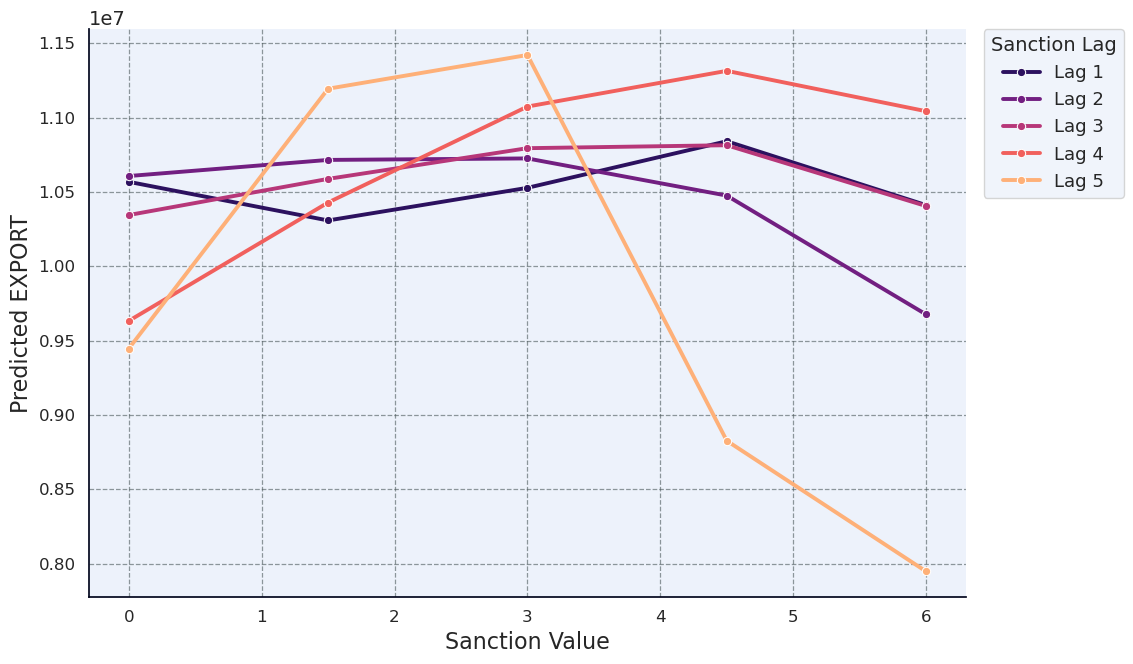

In [62]:
plt.figure(figsize=(11.5, 6.8))

ax = sns.lineplot(
  data=pdp_df,
  x="value",
  y="prediction",
  hue="sanction_lag",
  palette="magma",
  linewidth=2.8,  # thicker lines
  marker="o",  # markers for readability
  markersize=6
)

# Axis labels (larger fonts)
ax.set_xlabel("Sanction Value", fontsize=16)
ax.set_ylabel("Predicted EXPORT", fontsize=16)

# Tick label size
ax.tick_params(axis="both", labelsize=12)

# Grid: clearer but not dominant
ax.grid(
  True,
  which="major",
  linestyle="--",
  linewidth=0.9,
  alpha=0.6
)

handles, labels = ax.get_legend_handles_labels()

# Replace labels like "sanction_lag1" → "Lag 1"
new_labels = [f"Lag {i + 1}" for i in range(len(labels))]

ax.legend(
  handles,
  new_labels,
  title="Sanction Lag",
  title_fontsize=14,
  fontsize=13,
  loc="upper left",
  bbox_to_anchor=(1.02, 1.0),
  borderaxespad=0.0,
  frameon=True
)
# Remove title (already empty, but explicit)
ax.set_title("")
plt.savefig(
  f"../graph_output/pdp_{DYAD_NAME}-{SELECTED_MODEL}.png",
  dpi=500,
  bbox_inches="tight"
)
plt.tight_layout()
plt.show()

Ready to plot 30 dyads from DYAD_LIST.


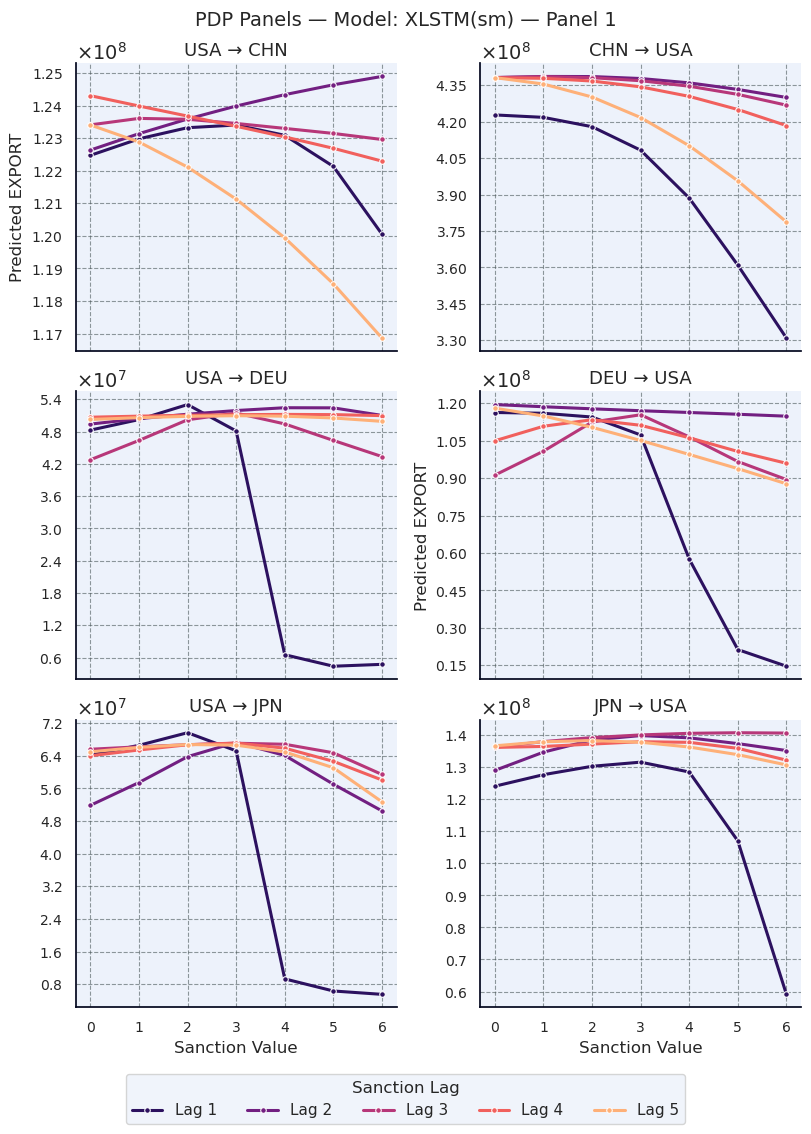

Saved: ../graph_output/pdp_panels/pdp_panels_XLSTM(sm)_001.png


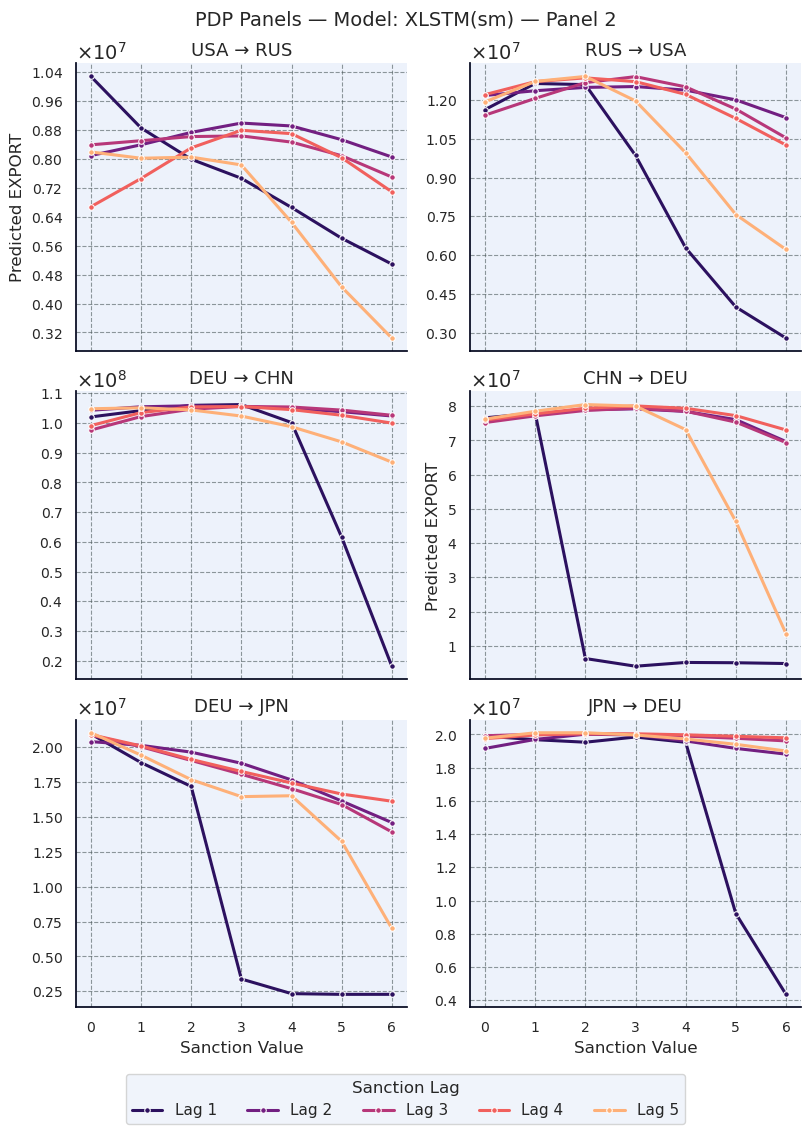

Saved: ../graph_output/pdp_panels/pdp_panels_XLSTM(sm)_002.png


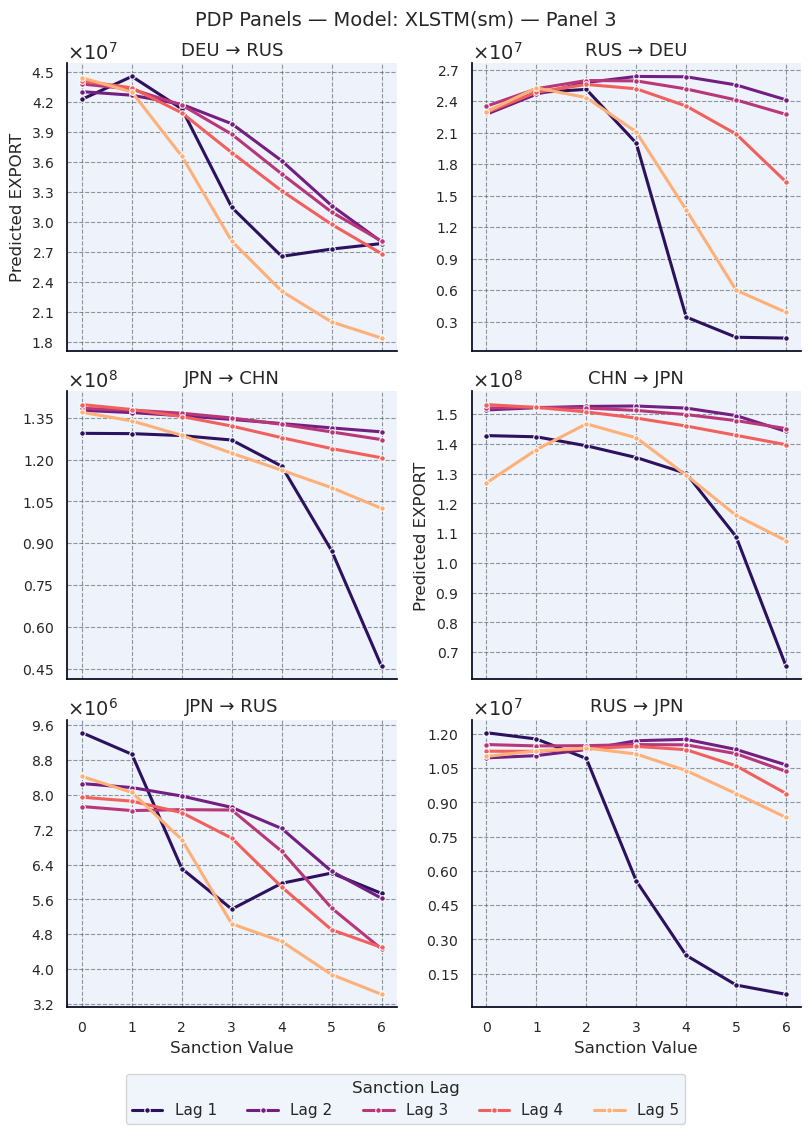

Saved: ../graph_output/pdp_panels/pdp_panels_XLSTM(sm)_003.png


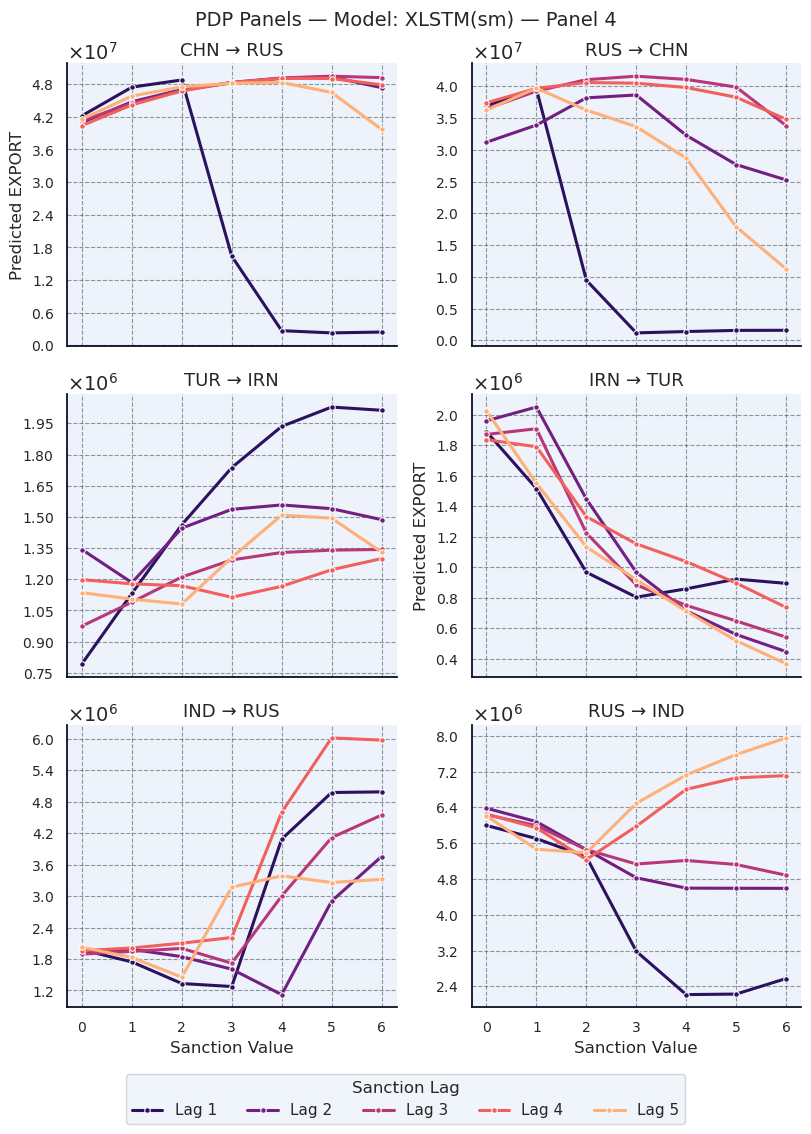

Saved: ../graph_output/pdp_panels/pdp_panels_XLSTM(sm)_004.png


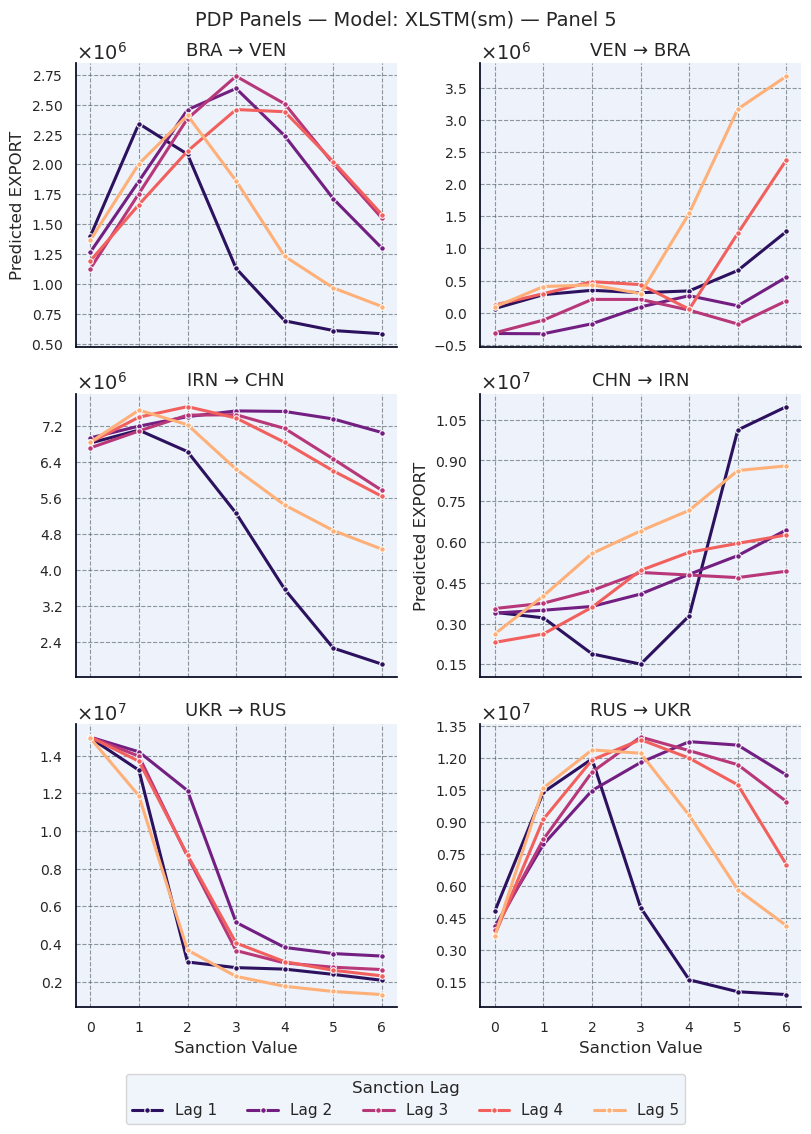

Saved: ../graph_output/pdp_panels/pdp_panels_XLSTM(sm)_005.png


In [63]:
# -----------------------------
# PDPs for a GIVEN LIST of dyads: 6 per panel
# -----------------------------

# >>> Put your dyads here (order will be preserved)
DYAD_LIST = DYADS_CASE_STUDY

GDP_QUANTILE = 0.75  # set to None if you do NOT want GDP override
N_LAGS = 5
SANCTION_VALUES = torch.arange(0, 7)
PANEL_SIZE = 6

OUT_DIR = Path("../graph_output/pdp_panels")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SANCTION_FEATURE_LAGS = [f"sanction_lag{i}" for i in range(1, N_LAGS + 1)]
GDP_FEATURE_LAGS = (
    [f"GDP_reporter_centered_lag{i}" for i in range(1, N_LAGS + 1)] +
    [f"GDP_partner_centered_lag{i}" for i in range(1, N_LAGS + 1)]
)

feature_to_index = { feat: i for i, feat in enumerate(FEATURES) }

median_export = df_nn["EXPORT"].median()
std_export = df_nn["EXPORT"].std()

# Reverse mapping for dataset dyad_idx -> dyad_name
idx_to_dyad = { v: k for k, v in dyad_to_idx.items() }


def ensure_1d_features(x: torch.Tensor) -> torch.Tensor:
  if x.ndim == 1:
    return x
  if x.ndim == 2 and x.shape[0] == 1:
    return x.squeeze(0)
  if x.ndim == 3 and x.shape[0] == 1 and x.shape[1] == 1:
    return x.squeeze(0).squeeze(0)
  if x.numel() == len(FEATURES):
    return x.reshape(-1)
  raise ValueError(f"Unexpected X shape {tuple(x.shape)}; cannot coerce to [F].")


def chunked(lst, n):
  for j in range(0, len(lst), n):
    yield lst[j:j + n]


# -----------------------------
# 0) Validate dyad list against dyad_to_idx
# -----------------------------
dyad_names = []
for d in DYAD_LIST:
  if d in dyad_to_idx:
    dyad_names.append(d)
  else:
    print(f"WARNING: dyad '{d}' not in dyad_to_idx -> skipped")

# de-duplicate while preserving order
seen = set()
dyad_names = [d for d in dyad_names if not (d in seen or seen.add(d))]

if len(dyad_names) == 0:
  raise ValueError("No valid dyads in DYAD_LIST after filtering.")

# -----------------------------
# 1) Precompute ONE X_fixed per requested dyad (single pass over dataset)
# -----------------------------
X_fixed_by_dyad = { }
needed = set(dyad_names)

for i in range(len(dataset)):
  X, y, dyad_idx, _ = dataset[i]
  dyad_idx_int = int(dyad_idx.item())
  dyad_name = idx_to_dyad.get(dyad_idx_int, None)

  if dyad_name is None or dyad_name not in needed:
    continue

  if dyad_name not in X_fixed_by_dyad:
    X_cpu = X.detach().cpu()
    try:
      X_cpu = ensure_1d_features(X_cpu)
    except ValueError as e:
      print(f"Skipping dyad {dyad_name}: {e}")
      continue
    X_fixed_by_dyad[dyad_name] = X_cpu.clone()

  if len(X_fixed_by_dyad) == len(needed):
    break

missing = [d for d in dyad_names if d not in X_fixed_by_dyad]
if missing:
  print(f"WARNING: No dataset sample found for {len(missing)} dyads -> skipped:", missing)

dyad_names = [d for d in dyad_names if d in X_fixed_by_dyad]

if len(dyad_names) == 0:
  raise ValueError("No dyads left to plot (none found in dataset).")

print(f"Ready to plot {len(dyad_names)} dyads from DYAD_LIST.")

# -----------------------------
# 2) Model setup once
# -----------------------------
model = models[SELECTED_MODEL]
model.eval()
model.to(device)


def compute_pdp_df_for_dyad(dyad_name: str) -> pd.DataFrame:
  X_fixed = X_fixed_by_dyad[dyad_name].clone()  # 1D [F]
  dyad_idx_value = dyad_to_idx[dyad_name]

  if X_fixed.ndim != 1 or X_fixed.shape[0] != len(FEATURES):
    print(f"Skipping {dyad_name}: X_fixed shape {tuple(X_fixed.shape)} != (F={len(FEATURES)})")
    return pd.DataFrame(columns=["sanction_lag", "value", "prediction"])

  # Optional GDP override
  if GDP_QUANTILE is not None:
    dyad_df = df_nn[df_nn["dyad_id"] == dyad_name]
    if not dyad_df.empty:
      gdp_q = dyad_df[GDP_FEATURE_LAGS].quantile(GDP_QUANTILE)
      for gdp_feat, qval in gdp_q.items():
        idx = feature_to_index.get(gdp_feat, None)
        if idx is not None:
          X_fixed[idx] = float(qval)

  pdp_records = []
  # AFTER
  lag_values = SANCTION_VALUES

  for lag_feat in SANCTION_FEATURE_LAGS:
    feat_idx = feature_to_index.get(lag_feat, None)
    if feat_idx is None:
      continue

    X_varied = X_fixed.unsqueeze(0).repeat(len(lag_values), 1)
    X_varied[:, feat_idx] = lag_values

    X_seq = X_varied.unsqueeze(1).to(device)
    dyads = torch.full((len(lag_values),), dyad_idx_value, dtype=torch.long).to(device)

    with torch.no_grad():
      preds = model(X_seq, dyads).squeeze().detach().cpu().numpy()

    preds = preds * std_export + median_export

    pdp_records.extend([
      { "sanction_lag": lag_feat, "value": float(v.item()), "prediction": float(p) }
      for v, p in zip(lag_values, preds)
    ])

  return pd.DataFrame(pdp_records)


# -----------------------------
# 3) Plot: 6 dyads per panel (2x3)
# -----------------------------
panel_idx = 0

for dyad_chunk in chunked(dyad_names, PANEL_SIZE):
  panel_idx += 1

  # A4 portrait (inches): 8.27 × 11.69
  fig, axes = plt.subplots(3, 2, figsize=(8.27, 11.69), sharex=True, sharey=False)
  axes = axes.flatten()

  legend_handles, legend_labels = None, None

  for ax_i, ax in enumerate(axes):
    if ax_i >= len(dyad_chunk):
      ax.axis("off")
      continue

    dyad_name = dyad_chunk[ax_i]
    pdp_df = compute_pdp_df_for_dyad(dyad_name)

    if pdp_df.empty:
      ax.set_title(dyad_name)
      ax.text(0.5, 0.5, "No PDP data", ha="center", va="center")
      ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.5)
      continue

    sns.lineplot(
      data=pdp_df,
      x="value",
      y="prediction",
      hue="sanction_lag",
      palette="magma",
      linewidth=2.2,
      marker="o",
      markersize=4,
      ax=ax,
      legend=(legend_handles is None)
    )

    # --- y-axis scientific notation (apply per subplot axis) ---
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))

    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=10, prune=None))

    ax.set_title(f"{dyad_name.replace('_', ' → ')}", fontsize=13)
    ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.6)

    if ax_i % 3 == 0:
      ax.set_ylabel("Predicted EXPORT", fontsize=12)
    else:
      ax.set_ylabel("")

    if ax_i >= 3:
      ax.set_xlabel("Sanction Value", fontsize=12)
    else:
      ax.set_xlabel("")

    ax.tick_params(axis="both", labelsize=10)

    if legend_handles is None:
      legend_handles, legend_labels = ax.get_legend_handles_labels()
      ax.get_legend().remove()
    else:
      leg = ax.get_legend()
      if leg is not None:
        leg.remove()

  # Shared legend
  if legend_handles and legend_labels:
    cleaned_handles, cleaned_labels = [], []
    for h, lab in zip(legend_handles, legend_labels):
      if isinstance(lab, str) and lab.startswith("sanction_lag"):
        try:
          lag_num = int(lab.replace("sanction_lag", ""))
          cleaned_handles.append(h)
          cleaned_labels.append(f"Lag {lag_num}")
        except:
          pass

    fig.legend(
      cleaned_handles,
      cleaned_labels,
      title="Sanction Lag",
      title_fontsize=12,
      fontsize=11,
      loc="lower center",
      bbox_to_anchor=(0.5, 0.02),
      ncol=5,
      frameon=True
    )

  fig.suptitle(
    f"PDP Panels — Model: {SELECTED_MODEL} — Panel {panel_idx}",
    fontsize=14,
  )
  plt.tight_layout(rect=[0, 0.07, 1, 1])

  out_path = OUT_DIR / f"pdp_panels_{SELECTED_MODEL}_{panel_idx:03d}.png"
  plt.savefig(out_path, dpi=450, bbox_inches="tight")
  plt.show()

  print(f"Saved: {out_path}")

## 2D PDP

In [101]:
def pdp_2d_gdp_reporter_vs_sanction(
    dyad_id: str,
    model_name: str = "GRU",
    gdp_partner_lag: int = 2,  # K in GDP_partner_centered_lagK
    sanction_lag: int = 1,  # J in sanction_lagJ
    sanc_min: float = 0.0,
    sanc_max: float = 5.0,
    n_gdp: int = 60,  # grid resolution along GDP
    n_sanc: int = 31,  # grid resolution along sanction
    batch_size: int = 2048,  # for fast batched inference
    uncenter_export: bool = False  # if True, convert predictions back to raw EXPORT units
):
  model = models[model_name].eval().to(device)

  # --- columns we’ll need ---
  gdp_rep = [f"GDP_reporter_centered_lag{i}" for i in range(1, 6)]
  gdp_par = [f"GDP_partner_centered_lag{i}" for i in range(1, 6)]
  sanc_cols = [f"sanction_lag{i}" for i in range(1, 6)]
  geo_cols = ["contig", "comlang_off", "colony", "smctry", "distw_centered"]
  feat_idx = { f: i for i, f in enumerate(FEATURES) }

  # --- dyad slice ---
  df_nn["dyad_id"] = df_nn["ISO3_reporter"] + "_" + df_nn["ISO3_partner"]
  dyad_df = df_nn[df_nn["dyad_id"] == dyad_id].copy()
  assert len(dyad_df), f"No rows for dyad {dyad_id}"
  dyad_idx_val = dyad_to_idx[dyad_id]

  # --- find one base sample from your dataset wrapper ---
  X_base = None
  for i in range(len(dataset)):
    X_i, _, dy_i, _ = dataset[i]
    if dy_i.item() == dyad_idx_val:
      X_base = X_i.clone()  # (1, D)
      break
  assert X_base is not None, f"No sample found for dyad {dyad_id}"

  # --- sanity: warn if geo is not constant ---
  for c in geo_cols:
    if dyad_df[c].nunique() != 1:
      print(f"[warn] {c} is not constant for {dyad_id}: {dyad_df[c].unique()}")

  # --- fix geography to a constant of this dyad ---
  for c in geo_cols:
    X_base[0, feat_idx[c]] = float(dyad_df[c].iloc[0])

  # --- fix ALL GDP lags to dyad Q75 (reporter & partner), we’ll vary only one reporter lag below ---
  q75 = dyad_df[gdp_rep + gdp_par].quantile(0.75)
  for c in (gdp_rep + gdp_par):
    X_base[0, feat_idx[c]] = float(q75[c])

  # --- fix ALL sanctions to 0 (we’ll vary only the chosen one below) ---
  for c in sanc_cols:
    X_base[0, feat_idx[c]] = 0.0

  # --- build grids (centered values) ---
  gdp_col = f"GDP_reporter_centered_lag{gdp_partner_lag}"
  sanc_col = f"sanction_lag{sanction_lag}"

  # GDP grid from dyad-specific min->max of the chosen lag (centered units)
  gdp_min = float(dyad_df[gdp_col].min())
  gdp_max = float(dyad_df[gdp_col].max())
  if not np.isfinite(gdp_min) or not np.isfinite(gdp_max) or abs(gdp_max - gdp_min) < 1e-9:
    # fall back to a small span if degenerate
    gdp_min, gdp_max = -0.5, 0.5
  gdp_grid = np.linspace(gdp_min, gdp_max, n_gdp)
  sanc_grid = np.linspace(sanc_min, sanc_max, n_sanc)

  # mesh
  G, S = np.meshgrid(gdp_grid, sanc_grid)  # shapes (n_sanc, n_gdp)

  # --- build a big batch of inputs for all grid points ---
  N = n_gdp * n_sanc
  X_batch = X_base.repeat(N, 1)  # (N, D)
  X_batch[:, feat_idx[gdp_col]] = torch.tensor(G.ravel(), dtype=torch.float32)
  X_batch[:, feat_idx[sanc_col]] = torch.tensor(S.ravel(), dtype=torch.float32)

  # Still keep *other* sanctions at 0 (already set). GDP partner & other reporter lags at Q75 (already set).

  # --- run model in batches ---
  preds = np.empty(N, dtype=np.float32)
  dyads_tensor = torch.full((N,), dyad_idx_val, dtype=torch.long, device=device)

  with torch.no_grad():
    for start in range(0, N, batch_size):
      end = min(start + batch_size, N)
      xb = X_batch[start:end].unsqueeze(1).to(device)  # (B, 1, D)
      dyb = dyads_tensor[start:end]
      preds[start:end] = model(xb, dyb).squeeze(-1).detach().cpu().numpy()

  # optional: convert EXPORT back to raw units
  if uncenter_export:
    export_median = df_nn["EXPORT"].median()
    export_std = df_nn["EXPORT"].std()
    preds = preds * export_std + export_median

  Z = preds.reshape(n_sanc, n_gdp)  # rows: sanction, cols: GDP

  # --- plot: heatmap & contourf side-by-side ---
  fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 6.5),
    sharey=True,
    gridspec_kw={ "wspace": 0.12 }
  )

  # Shared color scale
  vmin, vmax = np.nanmin(Z), np.nanmax(Z)

  # ----------------
  # Heatmap (left)
  # ----------------
  im = axes[0].imshow(
    Z,
    aspect="auto",
    origin="lower",
    cmap="magma",
    vmin=vmin,
    vmax=vmax,
    extent=[gdp_grid.min(), gdp_grid.max(), sanc_grid.min(), sanc_grid.max()]
  )

  axes[0].set_title(f"Heatmap — {dyad_id} | {model_name}", fontsize=15, pad=12)
  axes[0].set_xlabel(f"GDP Partner Lag {gdp_partner_lag}", fontsize=13)
  axes[0].set_ylabel(f"Sanction Lag {sanction_lag}", fontsize=14)

  axes[0].tick_params(axis="both", labelsize=11)
  axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6))
  axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

  # ----------------
  # Contour plot (right)
  # ----------------
  levels = np.linspace(vmin, vmax, 20)

  cf = axes[1].contourf(
    gdp_grid,
    sanc_grid,
    Z,
    levels=levels,
    cmap="magma",
    vmin=vmin,
    vmax=vmax
  )

  axes[1].contour(
    gdp_grid,
    sanc_grid,
    Z,
    levels=levels[::4],
    colors="black",
    linewidths=0.6,
    alpha=0.5
  )

  axes[1].set_title(f"Contour — {dyad_id} | {model_name}", fontsize=15, pad=12)
  axes[1].set_xlabel(f"GDP Partner Lag {gdp_partner_lag}", fontsize=13)

  # remove duplicate Y label but keep ticks
  axes[1].set_ylabel("")
  axes[1].tick_params(axis="both", labelsize=11)

  axes[1].set_axisbelow(False)

  # ----------------
  # Single shared colorbar (far right)
  # ----------------
  cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.035,
    pad=0.06
  )

  cbar.ax.tick_params(labelsize=11)
  cbar.set_label(
    "Predicted EXPORT US $ thousands",
    fontsize=14,
    labelpad=20
  )
  cb_formatter = ScalarFormatter(useMathText=True)
  cb_formatter.set_scientific(True)
  cb_formatter.set_powerlimits((0, 0))  # always show ×10^k

  cbar.ax.yaxis.set_major_formatter(cb_formatter)
  cbar.ax.yaxis.get_offset_text().set_size(11)

  plt.savefig(
    f"../graph_output/pdp2_panels/pdp2_{dyad_id}-{model_name}.png",
    dpi=600,
    bbox_inches="tight"
  )
  plt.show()


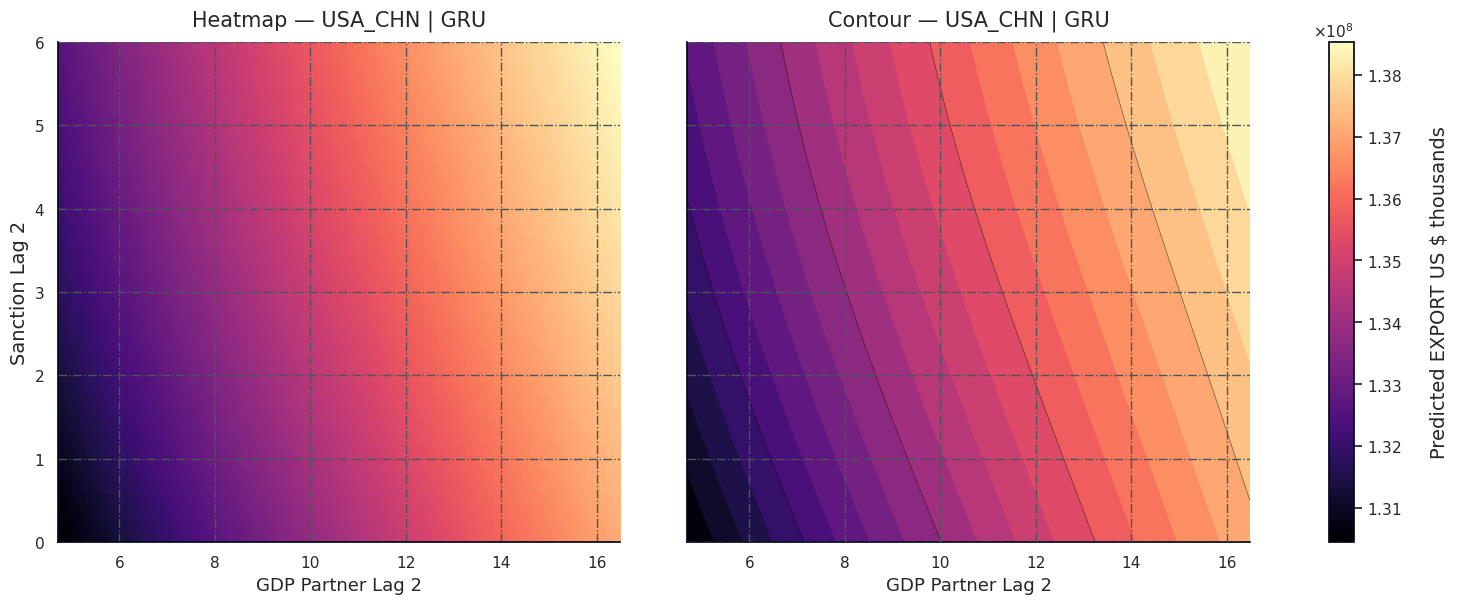

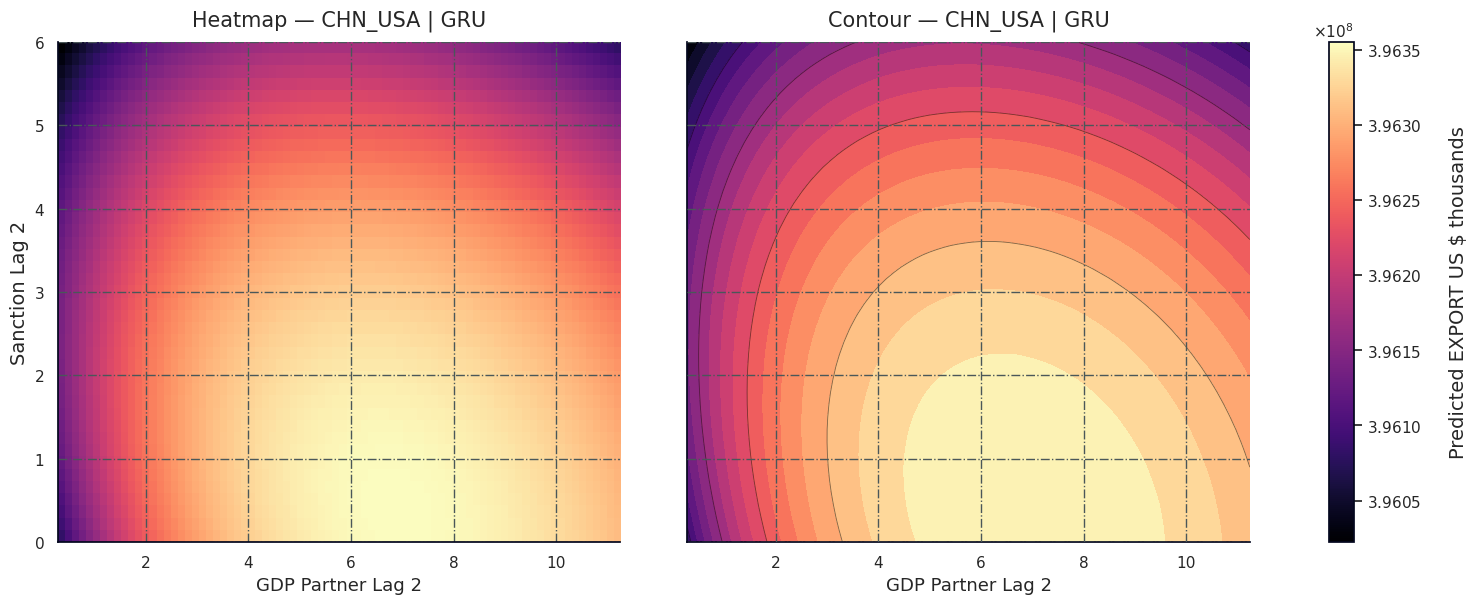

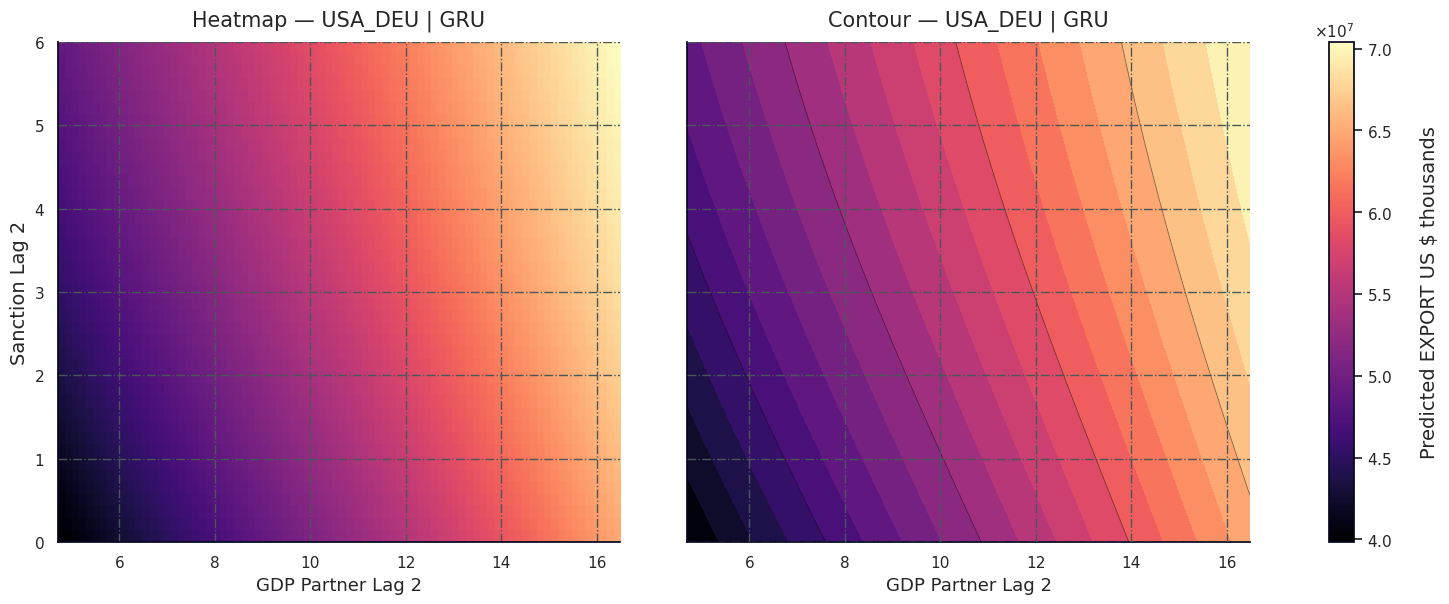

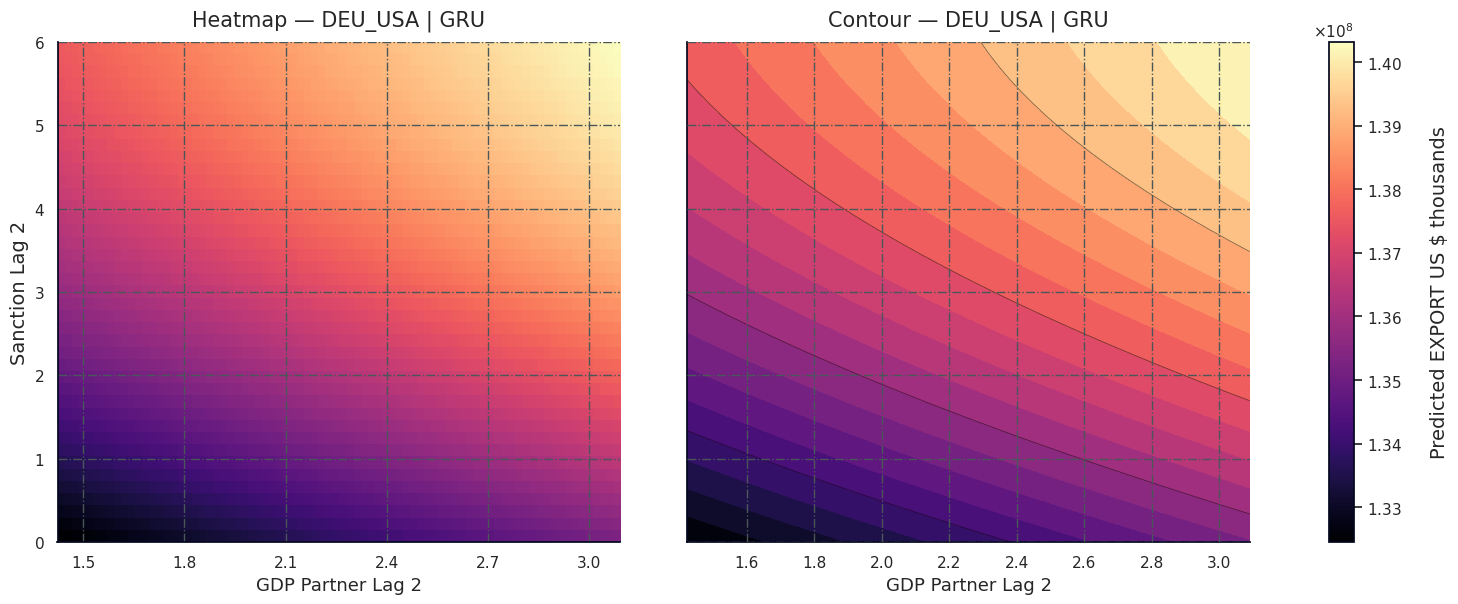

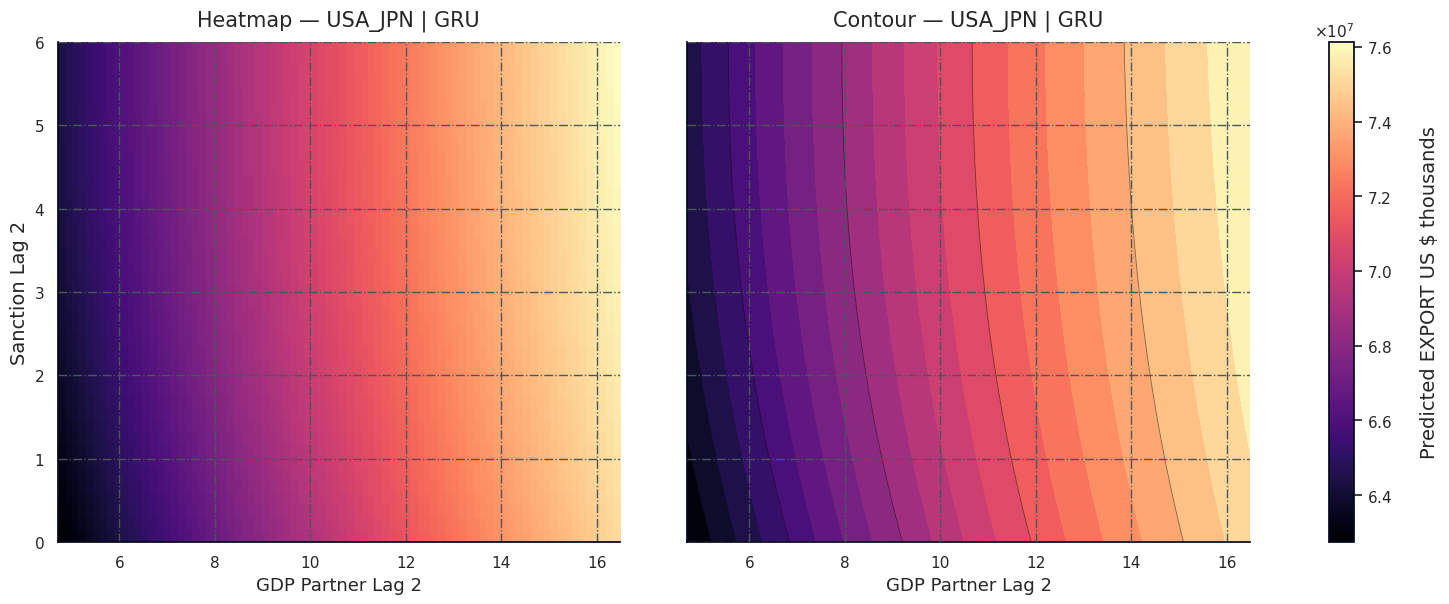

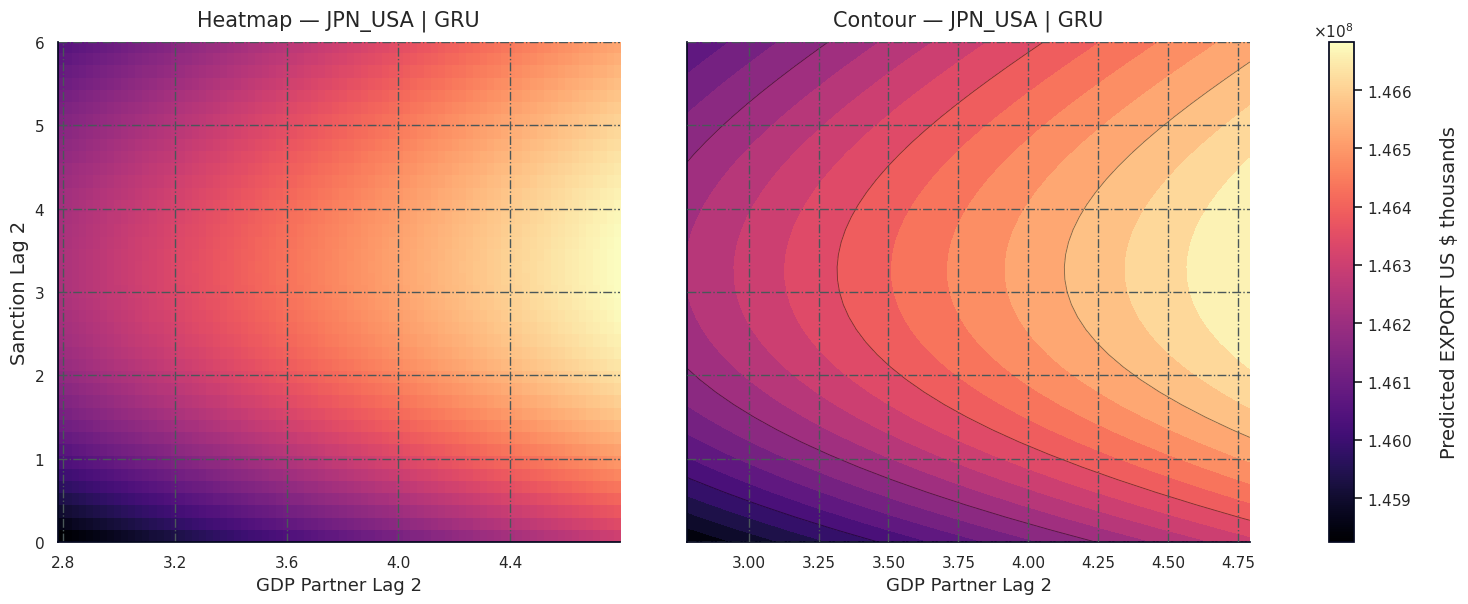

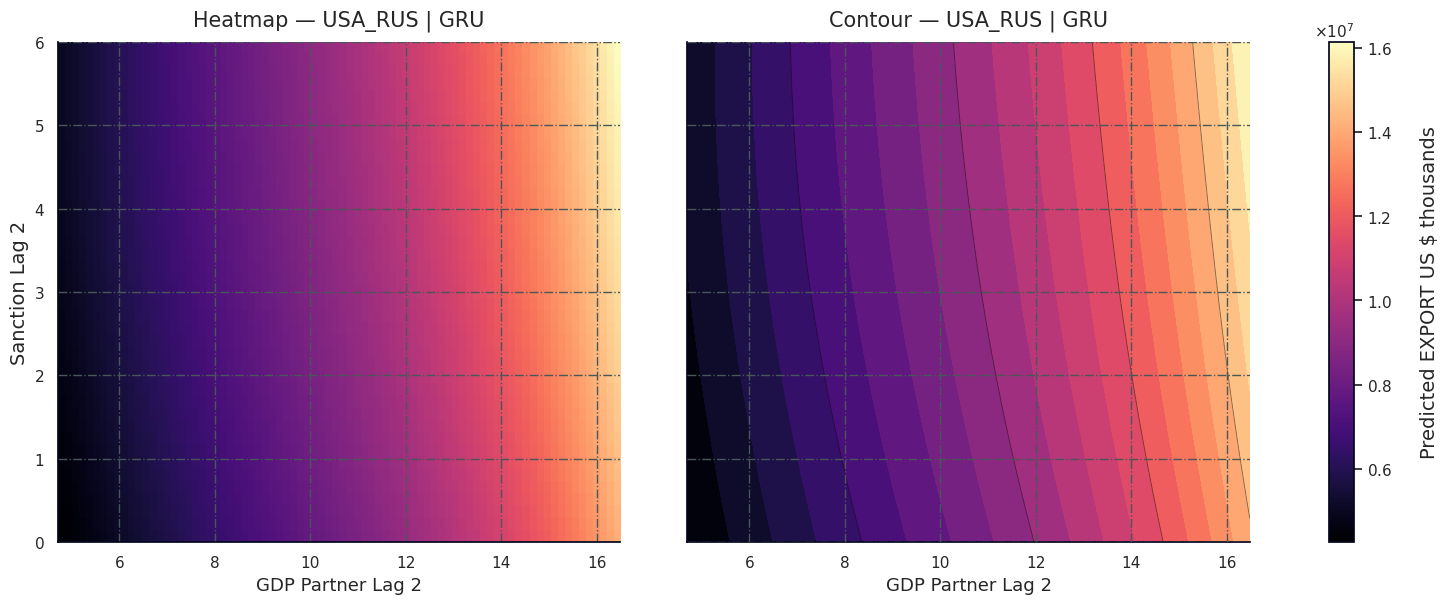

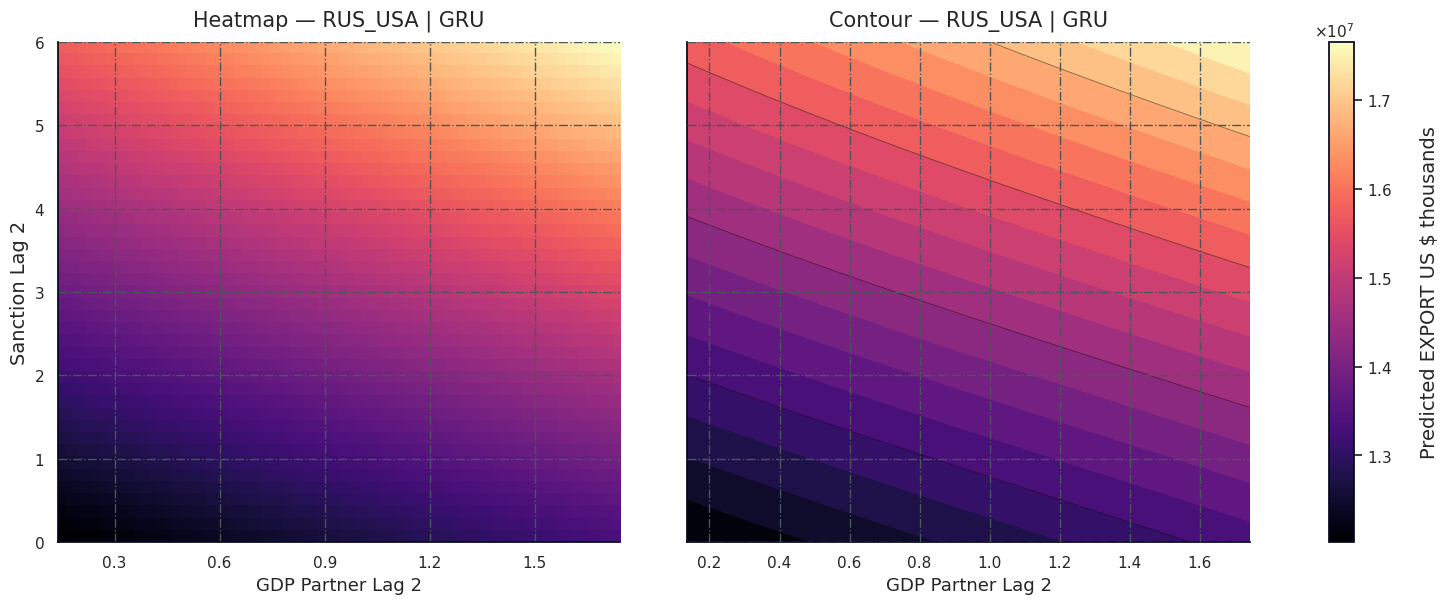

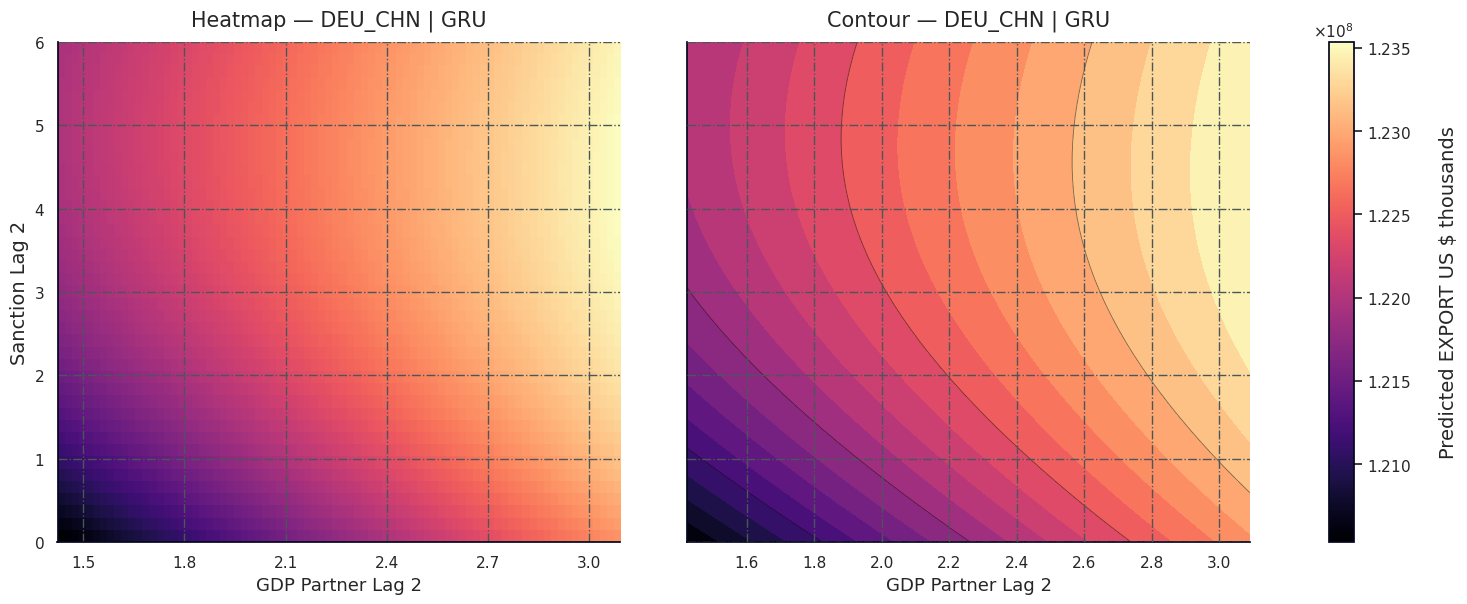

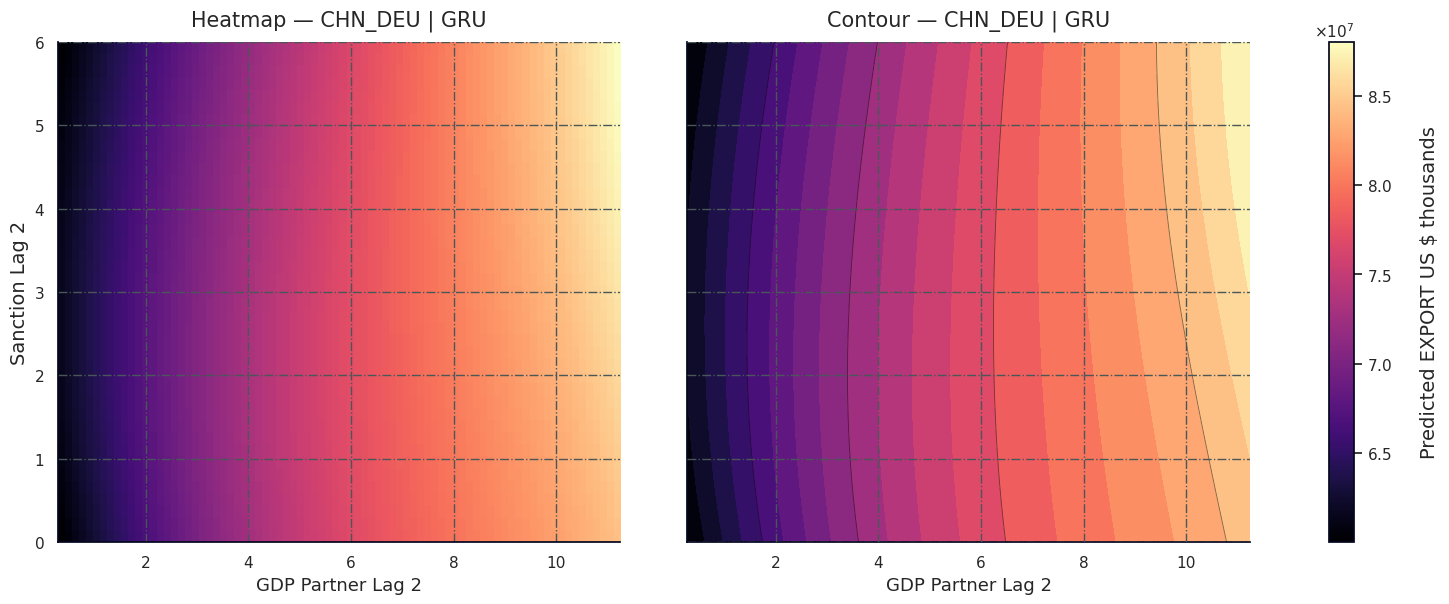

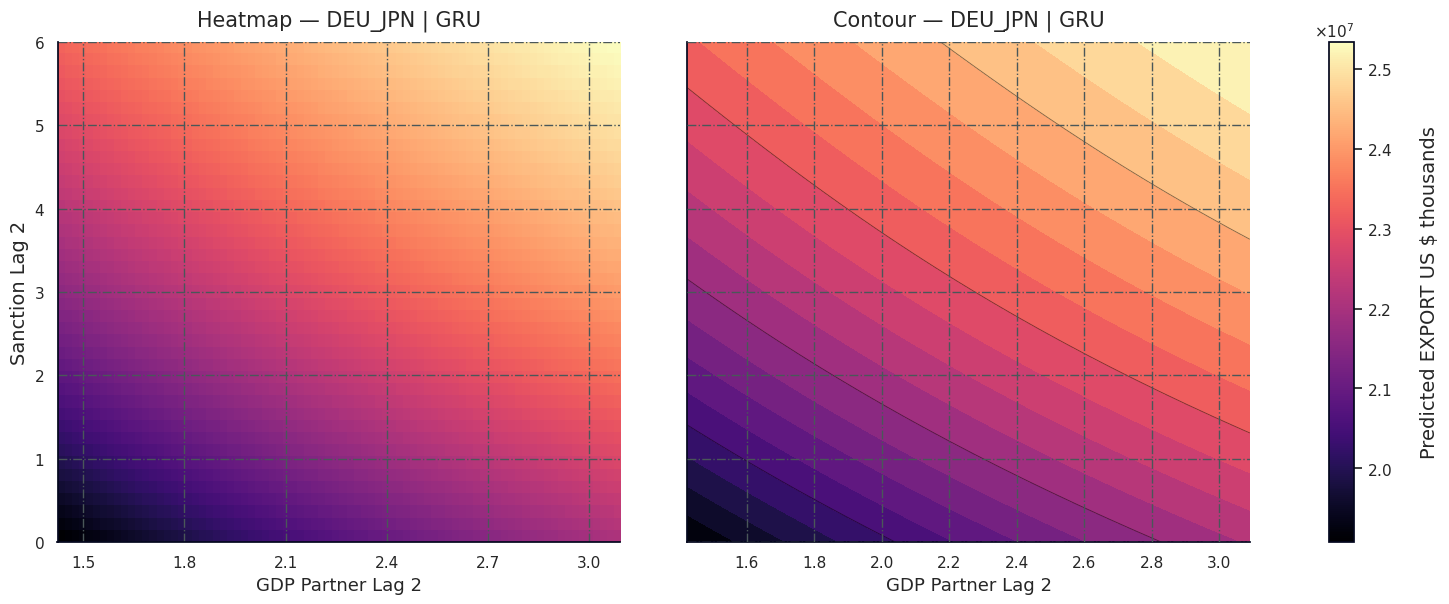

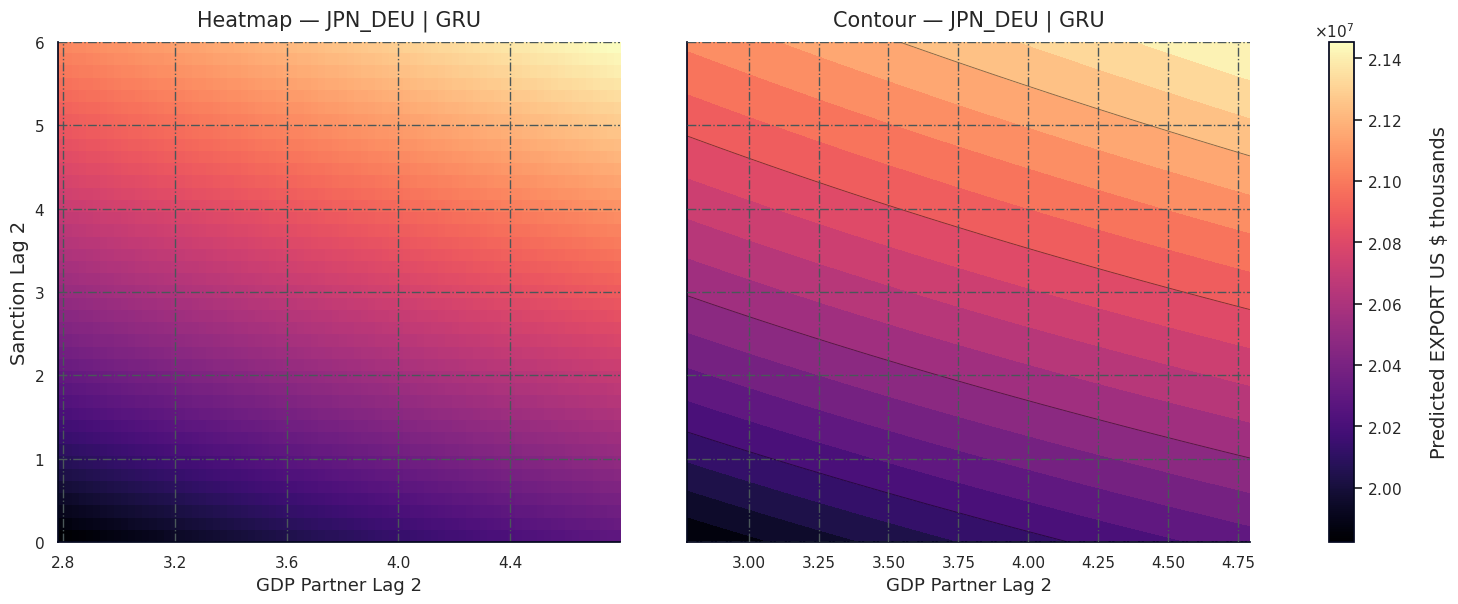

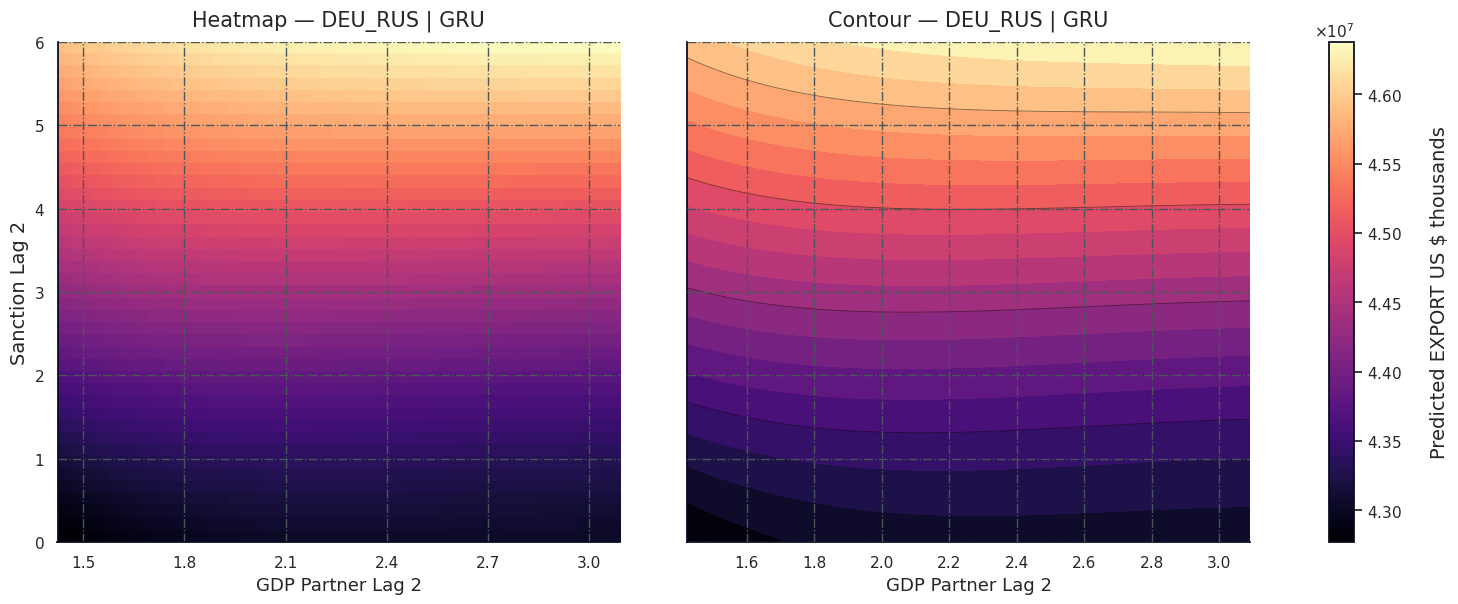

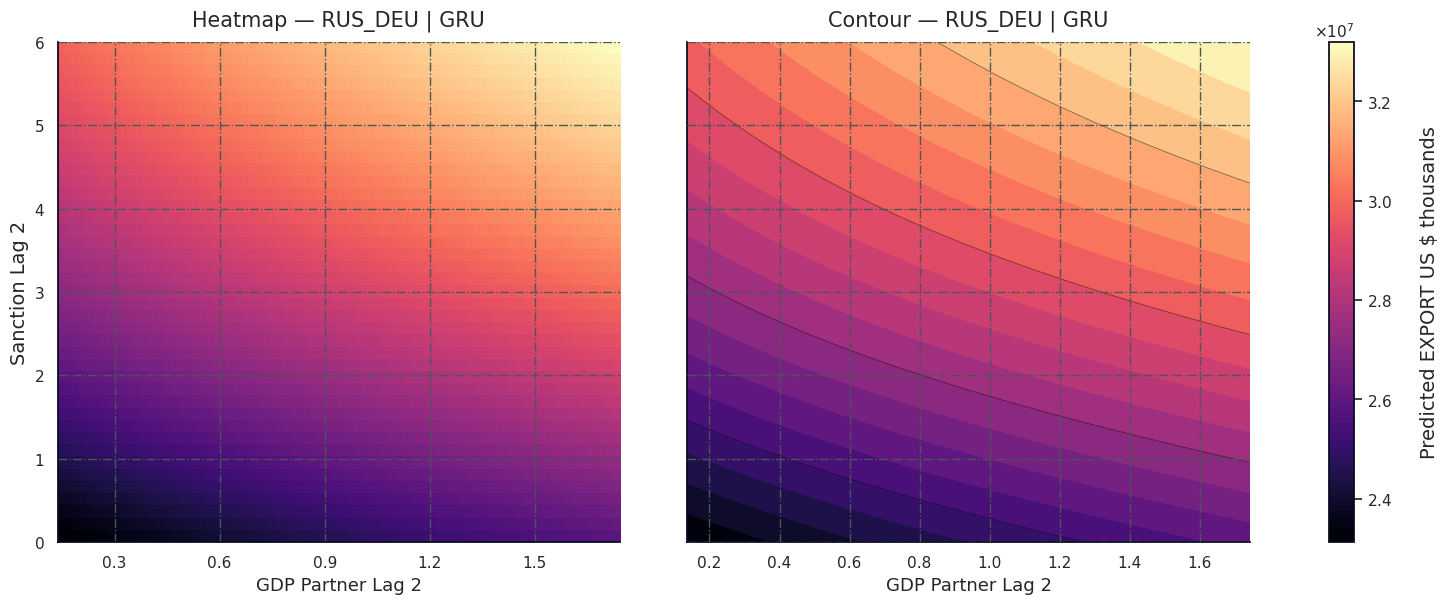

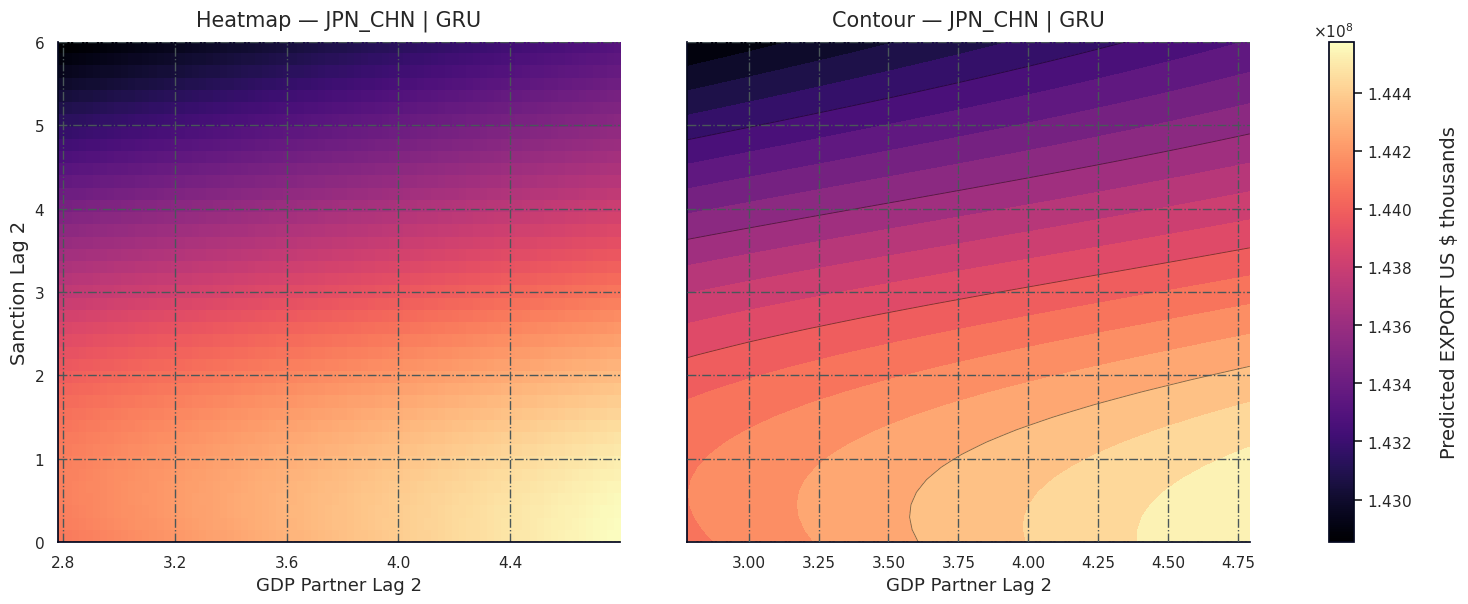

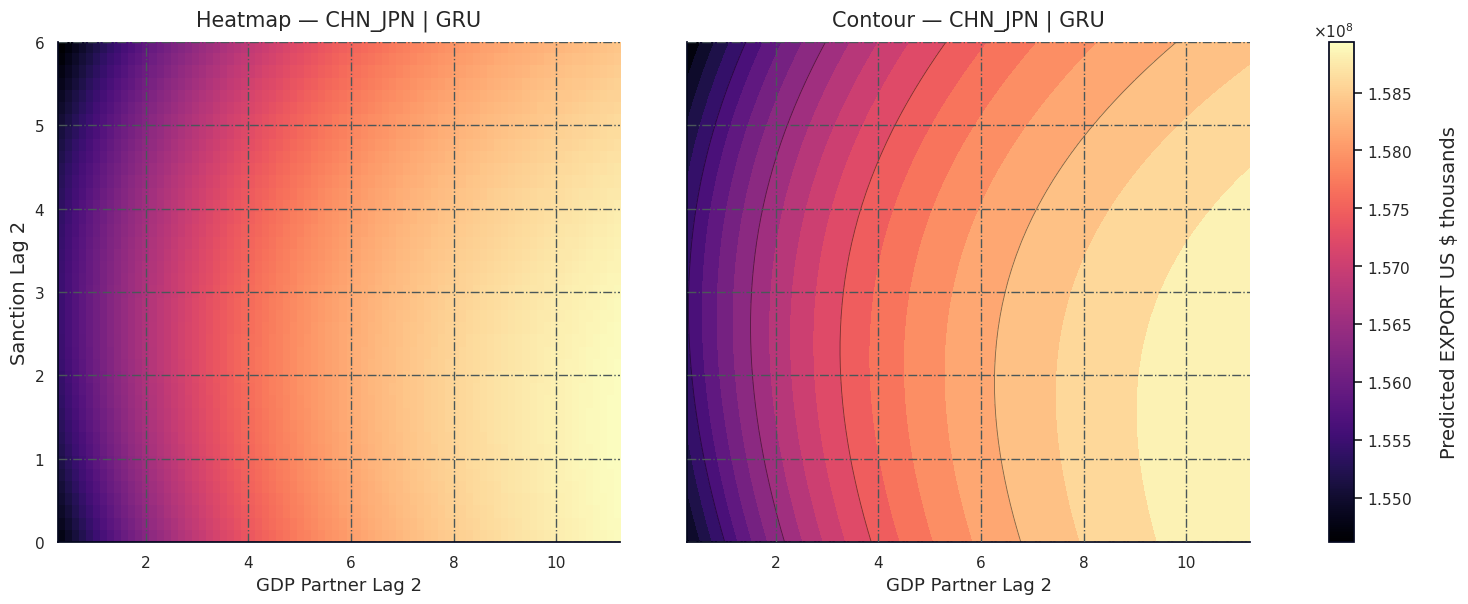

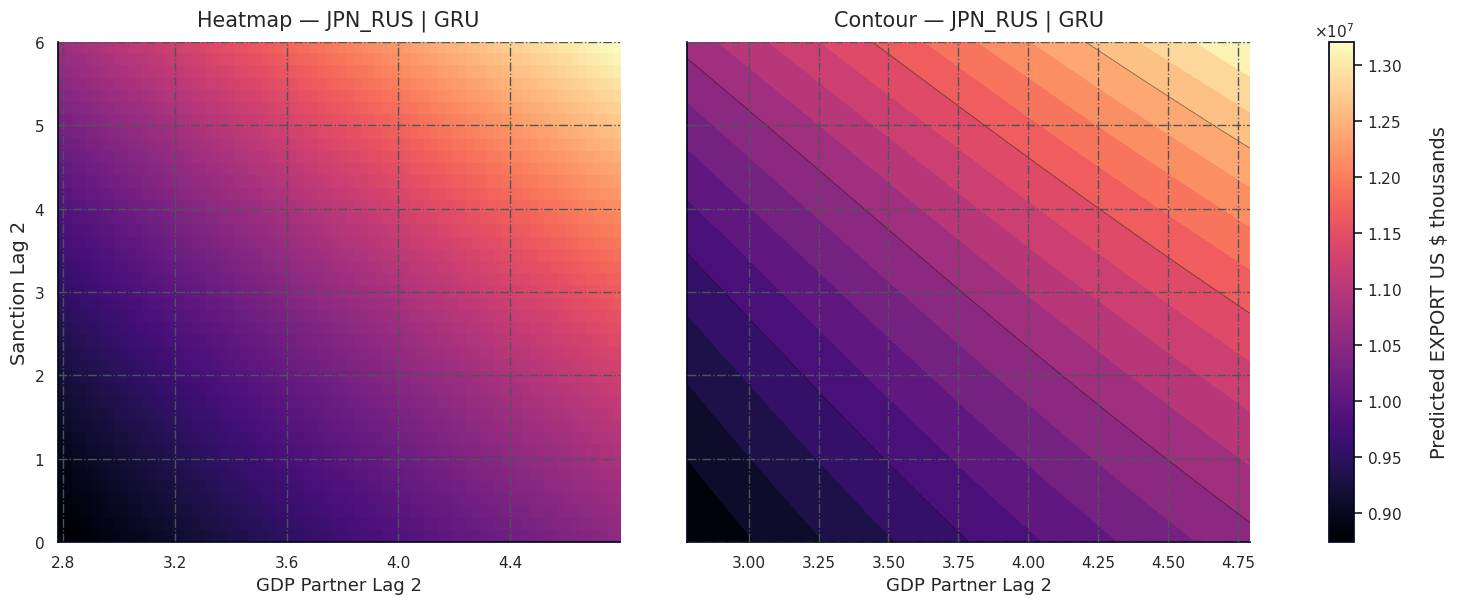

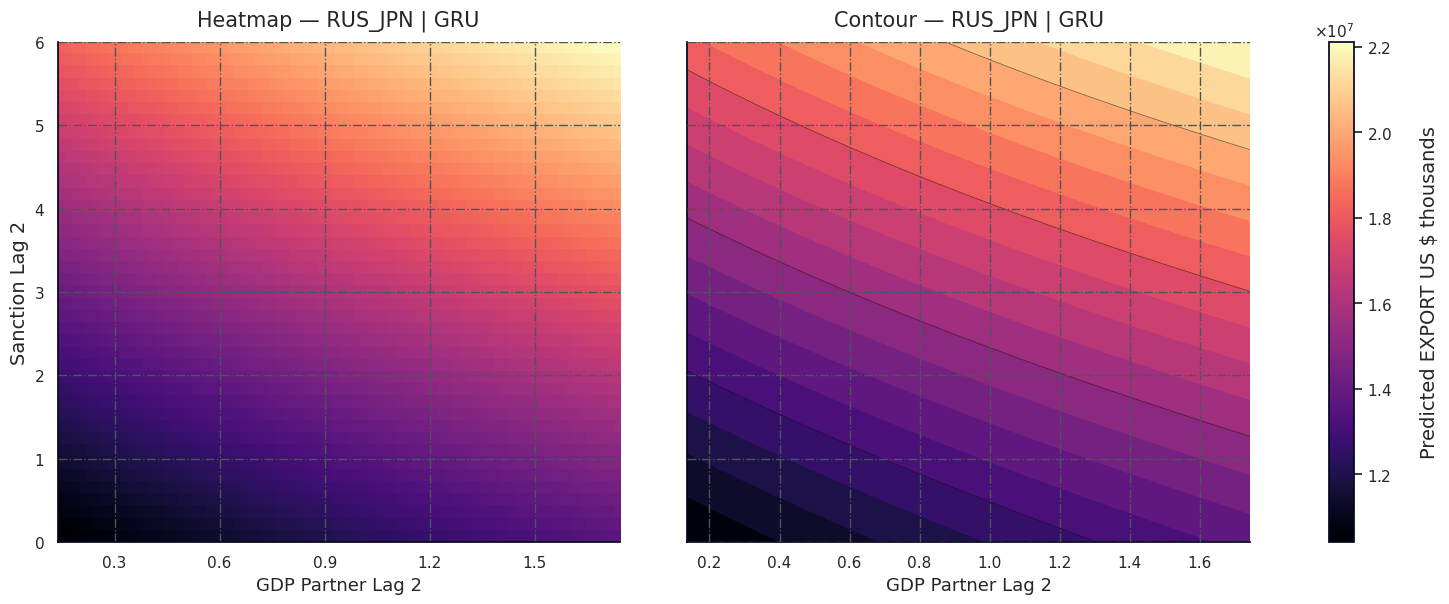

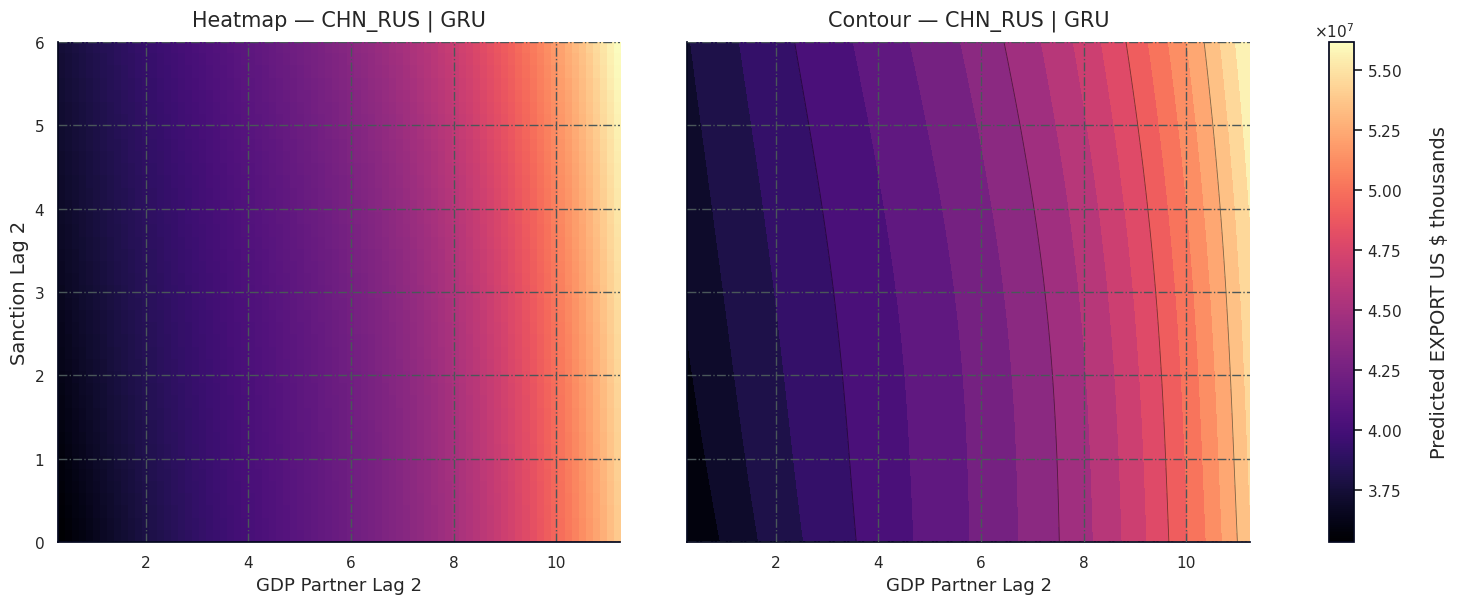

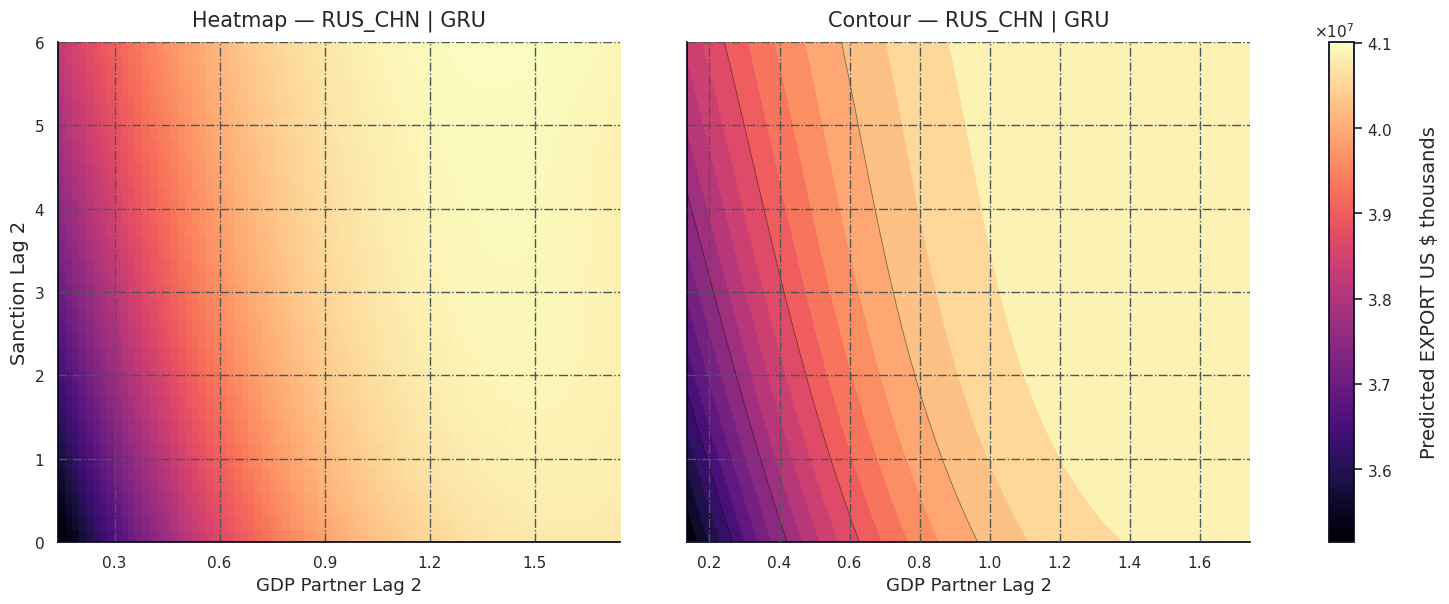

In [107]:
for dyad_name in DYADS_CASE_STUDY:
  pdp_2d_gdp_reporter_vs_sanction(
    dyad_id=dyad_name,
    model_name="GRU",
    gdp_partner_lag=2,
    sanction_lag=2,
    sanc_min=0.0,
    sanc_max=df_nn["sanction"].max(),
    n_gdp=80,
    n_sanc=41,
    batch_size=2048,
    uncenter_export=True,
  )

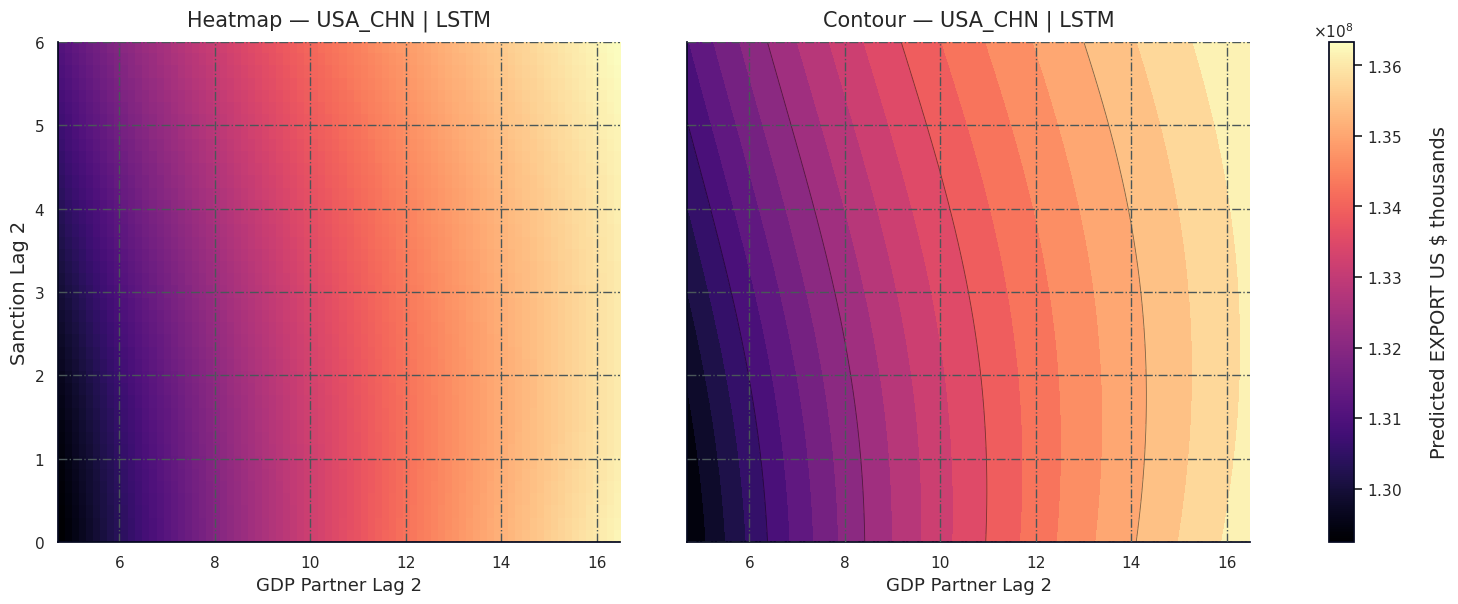

In [34]:
pdp_2d_gdp_reporter_vs_sanction(
  dyad_id=DYAD_NAME,
  model_name=SELECTED_MODEL,
  gdp_partner_lag=2,
  sanction_lag=2,
  sanc_min=0.0,
  sanc_max=df_nn["sanction"].max(),
  n_gdp=80,
  n_sanc=41,
  batch_size=2048,
  uncenter_export=True,
)

## 3D PDP

In [35]:
def pdp_3d_surface(
    dyad_id: str,
    model_name: str = "GRU",
    gdp_partner_lag: int = 2,
    sanction_lag: int = 1,
    sanc_min: float = 0.0,
    sanc_max: float = 5.0,
    n_gdp: int = 60,
    n_sanc: int = 31,
    batch_size: int = 2048,
    uncenter_export: bool = False
):
  # --- get model ---
  model = models[model_name].eval().to(device)

  gdp_rep = [f"GDP_reporter_centered_lag{i}" for i in range(1, 6)]
  gdp_par = [f"GDP_partner_centered_lag{i}" for i in range(1, 6)]
  sanc_cols = [f"sanction_lag{i}" for i in range(1, 6)]
  geo_cols = ["contig", "comlang_off", "colony", "smctry", "distw_centered"]
  feat_idx = { f: i for i, f in enumerate(FEATURES) }

  df_nn["dyad_id"] = df_nn["ISO3_reporter"] + "_" + df_nn["ISO3_partner"]
  dyad_df = df_nn[df_nn["dyad_id"] == dyad_id].copy()
  dyad_idx_val = dyad_to_idx[dyad_id]

  X_base = None
  for i in range(len(dataset)):
    X_i, _, dy_i, _ = dataset[i]
    if dy_i.item() == dyad_idx_val:
      X_base = X_i.clone()
      break

  for c in geo_cols:
    X_base[0, feat_idx[c]] = float(dyad_df[c].iloc[0])

  q75 = dyad_df[gdp_rep + gdp_par].quantile(0.75)
  for c in (gdp_rep + gdp_par):
    X_base[0, feat_idx[c]] = float(q75[c])

  for c in sanc_cols:
    X_base[0, feat_idx[c]] = 0.0

  gdp_col = f"GDP_reporter_centered_lag{gdp_partner_lag}"
  sanc_col = f"sanction_lag{sanction_lag}"

  gdp_min = float(dyad_df[gdp_col].min())
  gdp_max = float(dyad_df[gdp_col].max())
  gdp_grid = np.linspace(gdp_min, gdp_max, n_gdp)
  sanc_grid = np.linspace(sanc_min, sanc_max, n_sanc)

  G, S = np.meshgrid(gdp_grid, sanc_grid)

  N = n_gdp * n_sanc
  X_batch = X_base.repeat(N, 1)
  X_batch[:, feat_idx[gdp_col]] = torch.tensor(G.ravel(), dtype=torch.float32)
  X_batch[:, feat_idx[sanc_col]] = torch.tensor(S.ravel(), dtype=torch.float32)

  preds = np.empty(N, dtype=np.float32)
  dyads_tensor = torch.full((N,), dyad_idx_val, dtype=torch.long, device=device)

  with torch.no_grad():
    for start in range(0, N, batch_size):
      end = min(start + batch_size, N)
      xb = X_batch[start:end].unsqueeze(1).to(device)
      dyb = dyads_tensor[start:end]
      preds[start:end] = model(xb, dyb).squeeze(-1).cpu().numpy()

  if uncenter_export:
    export_median = df_nn["EXPORT"].median()
    export_std = df_nn["EXPORT"].std()
    preds = preds * export_std + export_median

  Z = preds.reshape(n_sanc, n_gdp)

  # --- 3D Surface Plot ---
  fig = plt.figure(figsize=(10, 6))
  ax = fig.add_subplot(111, projection="3d")
  surf = ax.plot_surface(G, S, Z, cmap="magma", edgecolor="none")
  ax.set_xlabel(f"{gdp_col} (centered)")
  ax.set_ylabel(f"{sanc_col}")
  ax.set_zlabel("Predicted EXPORT" + ("" if not uncenter_export else " (raw)"))
  ax.set_title(f"3D PDP — {dyad_id} | {model_name}", pad=20)
  ax.view_init(elev=20, azim=50)
  fig.colorbar(surf, ax=ax, shrink=0.5, aspect=8)
  plt.show()

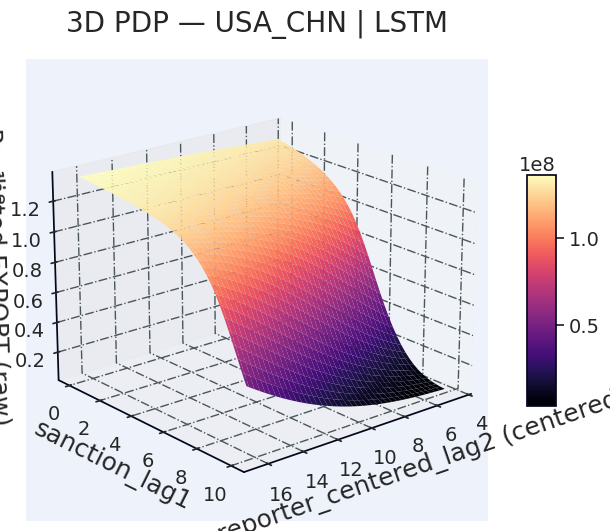

In [36]:
pdp_3d_surface(
  dyad_id="USA_CHN",
  model_name=SELECTED_MODEL,
  gdp_partner_lag=2,
  sanction_lag=1,
  sanc_min=0.0,
  sanc_max=10.0,
  n_gdp=80,
  n_sanc=41,
  batch_size=2048,
  uncenter_export=True,
)